# Comparative Analysis of Synthetic Data Trials
**Author:** Ayemhenre Isikhuemhen  
**Trials:** Trial 1 · Trial 3 · Trial 4 · Trial 5 · Trial 6 · Trial 7 · Trial 8 · Trial 9  
**Reference Dataset:** SFMTA Ridership by Route (Original)  
**Source:** Valmistada Synthetic Data Simulation — SD_Game Output  

**File Description:** This notebook performs a comparative analysis of eight synthetic simulation trials across four generation models: Deterministic, High-Fidelity, Rule-Based v1, and Rule-Based v2. Each model is run in Head (40 routes) and Full (67 routes) configurations. Sections 1 through 4 profile each model independently. Section 5 compares all Full-network trials against the original SFMTA ridership data.

## Setup
Setup for the comparative analysis notebook: Import Libraries and File Paths

In [1]:
# Library Imports
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Libraries Imported")

Libraries Imported


In [2]:
# File Paths

# Update BASE_DIR, MODIFIER_DIR, and GTFS_DIR if running on a different machine.
BASE_DIR     = r"C:\Users\Owner\Documents\GitHub\Valmistada\SD_Game\output\trials"
MODIFIER_DIR = r"C:\Users\Owner\Documents\GitHub\Valmistada\Data Exploration\Modifier Data\San Francisco"
GTFS_DIR     = r"C:\Users\Owner\Documents\GitHub\Valmistada\SD_Game\data\gtfs\San Francisco (muni_gtfs-current)"

import os

TRIAL_META = {
    "Trial 1" : {"dir": os.path.join(BASE_DIR, "trial_1"), "model": "Deterministic",  "mode": "Head"},
    "Trial 3" : {"dir": os.path.join(BASE_DIR, "trial_3"), "model": "High-Fidelity",  "mode": "Head"},
    "Trial 4" : {"dir": os.path.join(BASE_DIR, "trial_4"), "model": "Rule-Based v1",  "mode": "Head"},
    "Trial 5" : {"dir": os.path.join(BASE_DIR, "trial_5"), "model": "Deterministic",  "mode": "Full"},
    "Trial 6" : {"dir": os.path.join(BASE_DIR, "trial_6"), "model": "High-Fidelity",  "mode": "Full"},
    "Trial 7" : {"dir": os.path.join(BASE_DIR, "trial_7"), "model": "Rule-Based v1",  "mode": "Full"},
    "Trial 8" : {"dir": os.path.join(BASE_DIR, "trial_8"), "model": "Rule-Based v2",  "mode": "Head"},
    "Trial 9" : {"dir": os.path.join(BASE_DIR, "trial_9"), "model": "Rule-Based v2",  "mode": "Full"},
}

RIDERSHIP_PATH   = os.path.join(MODIFIER_DIR, "RidershipbyRouteTableDownload.csv")
GTFS_ROUTES_PATH = os.path.join(GTFS_DIR, "routes.txt")

COLORS = {
    "Trial 1": "#1565C0", "Trial 3": "#2E7D32", "Trial 4": "#6A1B9A",
    "Trial 5": "#1565C0", "Trial 6": "#2E7D32", "Trial 7": "#6A1B9A",
    "Trial 8": "#BF360C", "Trial 9": "#BF360C", "Original": "#37474F",
}

print("Paths Configured")

Paths Configured


In [3]:
# Data Loading

def load_trial(trial_dir):
    frames = []
    if not os.path.isdir(trial_dir):
        print(f"  WARNING: Directory not found: {trial_dir}")
        return pd.DataFrame()
    for fname in sorted(os.listdir(trial_dir)):
        if fname.lower().endswith((".csv", ".txt")):
            try:
                frames.append(pd.read_csv(os.path.join(trial_dir, fname)))
            except Exception as e:
                print(f"  Could not load {fname}: {e}")
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

trials_raw = {name: load_trial(meta["dir"]) for name, meta in TRIAL_META.items()}
rd_raw     = pd.read_csv(RIDERSHIP_PATH)

if os.path.exists(GTFS_ROUTES_PATH):
    gtfs_routes_raw = pd.read_csv(GTFS_ROUTES_PATH)
else:
    gtfs_routes_raw = pd.DataFrame()
    print(f"  WARNING: GTFS routes file not found: {GTFS_ROUTES_PATH}")

print("Files Loaded:")
for name, df in trials_raw.items():
    meta = TRIAL_META[name]
    print(f"  {name:<10} [{meta['model']:<16} / {meta['mode']:<5}] : {df.shape[0]:>8,} rows")
print(f"  {'Original':<10}                          : {rd_raw.shape[0]:>8,} rows")
print(f"  {'GTFS routes':<10}                        : {gtfs_routes_raw.shape[0]:>8,} rows")


Files Loaded:
  Trial 1    [Deterministic    / Head ] :    1,480 rows
  Trial 3    [High-Fidelity    / Head ] :    1,480 rows
  Trial 4    [Rule-Based v1    / Head ] :    1,480 rows
  Trial 5    [Deterministic    / Full ] :    2,479 rows
  Trial 6    [High-Fidelity    / Full ] :    2,479 rows
  Trial 7    [Rule-Based v1    / Full ] :    2,479 rows
  Trial 8    [Rule-Based v2    / Head ] :    1,480 rows
  Trial 9    [Rule-Based v2    / Full ] :    2,479 rows
  Original                            :   13,132 rows
  GTFS routes                        :        0 rows


In [4]:
# Data Cleaning

def clean_trial(df):
    if df.empty:
        return df
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]
    df["Average Daily Boardings"] = pd.to_numeric(
        df["Average Daily Boardings"].astype(str).str.replace(",", "").str.strip(),
        errors="coerce"
    )
    df["Month"] = pd.to_datetime(df["Month"], format="%B %Y", errors="coerce")
    df["Route"] = df["Route"].astype(str).str.strip()
    df = df[df["Month"].dt.year == 2019]
    return df.dropna(subset=["Average Daily Boardings", "Route"])

trials = {name: clean_trial(df) for name, df in trials_raw.items()}

# Clean original
rd = rd_raw.copy()
rd.columns = [c.strip() for c in rd.columns]
rd["Average Daily Boardings"] = pd.to_numeric(
    rd["Average Daily Boardings"].astype(str).str.replace(",", "").str.strip(), errors="coerce"
)
rd["Month"] = pd.to_datetime(rd["Month"], format="%B %Y", errors="coerce")
rd = rd.dropna(subset=["Average Daily Boardings", "Month"])
rd["Route"] = rd["Route"].astype(str).str.strip()

# Restrict original comparisons to 2019 for consistency with the synthetic trials.
rd_2019 = rd[rd["Month"].dt.year == 2019].copy()
original_by_route = rd_2019.groupby("Route")["Average Daily Boardings"].mean()

print(f"Original comparison year : 2019")
print(f"Original 2019 rows       : {len(rd_2019):,}")


Original comparison year : 2019
Original 2019 rows       : 2,274


## Section 1 Deterministic Model
**Trials:** Trial 1 (Head) · Trial 5 (Full)

**Description:** The Deterministic model removes all stochastic noise. Every run with the same inputs produces identical output, making it useful for isolating what the underlying network mechanics produce without randomness.

### 1.1 Overview

In [5]:
# Trial 1 DF Setup
df_trial_1 = trials["Trial 1"]

In [6]:
# Shape and Columns
print(f"Shape    : {trials['Trial 1'].shape}")
print(f"Columns  : {list(trials['Trial 1'].columns)}")

Shape    : (1440, 5)
Columns  : ['Month', 'Route', 'Service Category', 'Service Day of the Week', 'Average Daily Boardings']


In [7]:
# Trial 1 Summary Statistics
df = trials["Trial 1"]
print(f"Records  : {len(df):,}")
print(f"Routes   : {df['Route'].nunique()}")
print(f"Min      : {df['Average Daily Boardings'].min():,.0f}")
print(f"Median   : {df['Average Daily Boardings'].median():,.0f}")
print(f"Max      : {df['Average Daily Boardings'].max():,.0f}")
print(f"Std      : {df['Average Daily Boardings'].std():,.0f}")

Records  : 1,440
Routes   : 40
Min      : 1,290
Median   : 1,898
Max      : 2,708
Std      : 459


In [8]:
# Display Trial 1
display(trials["Trial 1"].head(10))

,Month,Route,Service Category,Service Day of the Week,Average Daily Boardings
0,2019-04-01,1,Bus,Weekday,2646
1,2019-04-01,12,Bus,Weekday,2646
2,2019-04-01,14,Bus,Weekday,2646
3,2019-04-01,14R,Bus,Weekday,2646
4,2019-04-01,15,Bus,Weekday,2646
5,2019-04-01,18,Bus,Weekday,2646
6,2019-04-01,19,Bus,Weekday,2646
7,2019-04-01,1X,Bus,Weekday,2646
8,2019-04-01,2,Bus,Weekday,2646
9,2019-04-01,22,Bus,Weekday,2646


In [9]:
# Trial 5 Summary Statistics
df = trials["Trial 5"]
print(f"Records  : {len(df):,}")
print(f"Routes   : {df['Route'].nunique()}")
print(f"Min      : {df['Average Daily Boardings'].min():,.0f}")
print(f"Median   : {df['Average Daily Boardings'].median():,.0f}")
print(f"Max      : {df['Average Daily Boardings'].max():,.0f}")
print(f"Std      : {df['Average Daily Boardings'].std():,.0f}")

Records  : 2,412
Routes   : 67
Min      : 500
Median   : 654
Max      : 1,377
Std      : 112


In [10]:
# Display Trial 5
display(trials["Trial 5"].head(10))

,Month,Route,Service Category,Service Day of the Week,Average Daily Boardings
0,2019-04-01,1,Bus,Weekday,773
1,2019-04-01,12,Bus,Weekday,839
2,2019-04-01,14,Bus,Weekday,839
3,2019-04-01,15,Bus,Weekday,773
4,2019-04-01,18,Bus,Weekday,773
5,2019-04-01,19,Bus,Weekday,978
6,2019-04-01,2,Bus,Weekday,648
7,2019-04-01,22,Bus,Weekday,773
8,2019-04-01,23,Bus,Weekday,839
9,2019-04-01,24,Bus,Weekday,978


### 1.2 Boarding Distribution

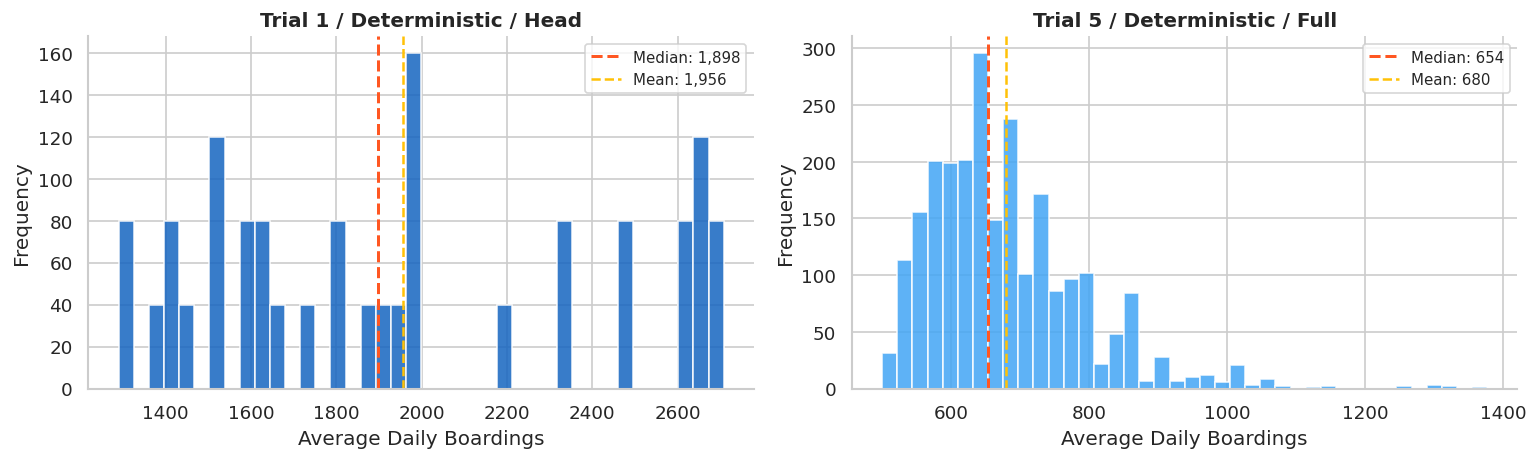

In [11]:
# Visualization: Boarding Distribution

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, t_name, col in [(axes[0], "Trial 1", "#1565C0"), (axes[1], "Trial 5", "#42A5F5")]:
    vals = trials[t_name]["Average Daily Boardings"].dropna()
    ax.hist(vals, bins=40, color=col, edgecolor="white", alpha=0.85)
    ax.axvline(vals.median(), color="#FF5722", linestyle="--", linewidth=1.8,
               label=f"Median: {vals.median():,.0f}")
    ax.axvline(vals.mean(), color="#FFC107", linestyle="--", linewidth=1.5,
               label=f"Mean: {vals.mean():,.0f}")
    meta = TRIAL_META[t_name]
    ax.set_title(f"{t_name} / {meta['model']} / {meta['mode']}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Average Daily Boardings")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Trial 1 shows nearly all 40 routes clustered at a single boarding value around 2,346, with median 1,898 and a narrow standard deviation of 459. Without noise, the model produces the same output for every route in the head selection. Trial 5 opens up slightly with 67 routes spanning 500 to 1,377, but the distribution remains tight. The spread in Trial 5 comes entirely from differences in stop count and spacing across the larger route set, not from stochastic variation.

### 1.3 Top 25 Routes by Total Boardings

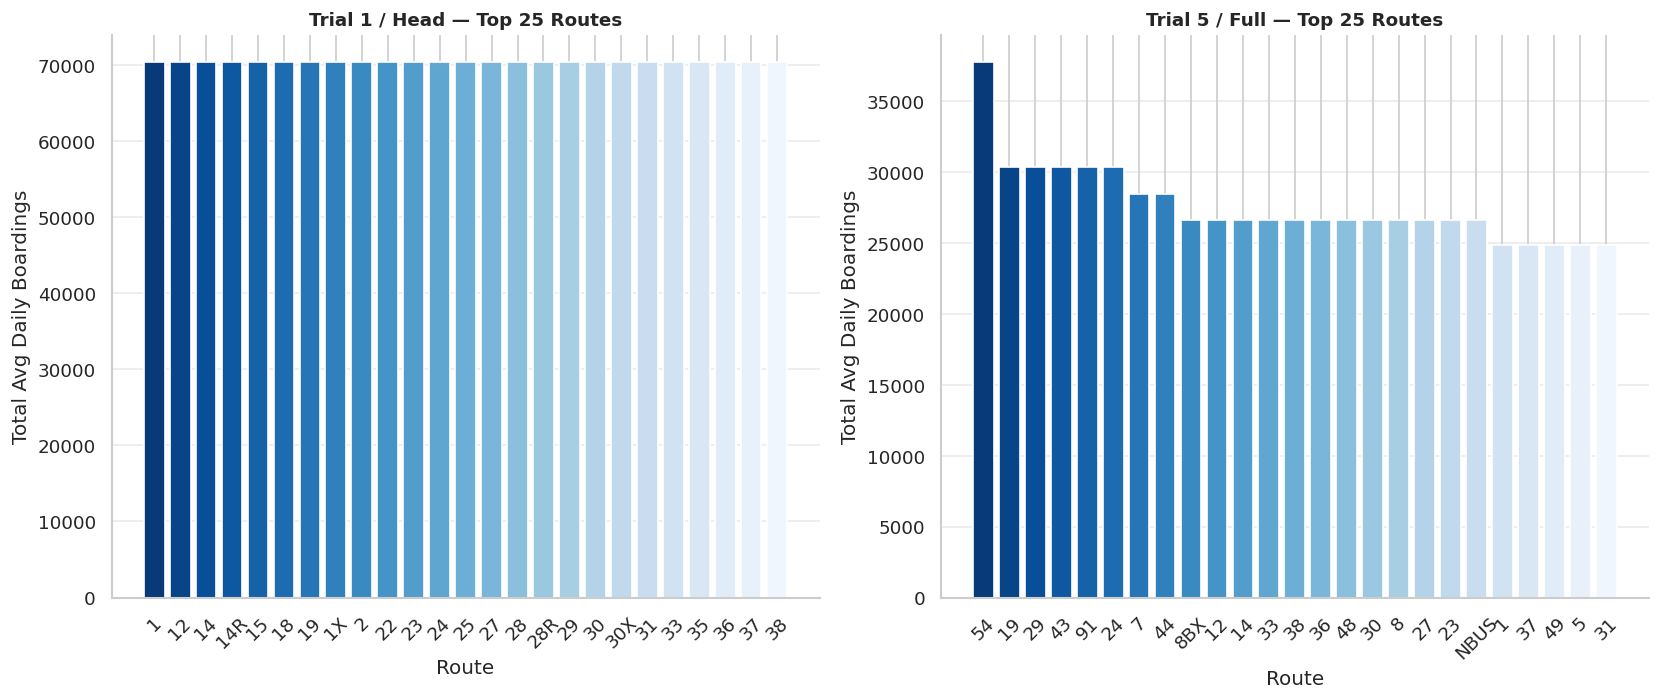

In [12]:
# Visualization: Top 25 Routes by Total Boardings

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, t_name, col in [(axes[0], "Trial 1", "#1565C0"), (axes[1], "Trial 5", "#42A5F5")]:
    df = trials[t_name]
    route_totals = df.groupby("Route")["Average Daily Boardings"].sum().sort_values(ascending=False).head(25)
    palette = sns.color_palette("Blues_r", len(route_totals))
    ax.bar(route_totals.index.astype(str), route_totals.values, color=palette, edgecolor="white")
    meta = TRIAL_META[t_name]
    ax.set_title(f"{t_name} / {meta['mode']} — Top 25 Routes", fontsize=11, fontweight="bold")
    ax.set_xlabel("Route")
    ax.set_ylabel("Total Avg Daily Boardings")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.4)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

In Trial 1, nearly all 25 bars are the same height, confirming that the head route selection receives uniform treatment from the deterministic mechanics. Trial 5 shows mild differentiation with routes 19, 28, and 14 pulling slightly ahead due to their longer stop sequences. The flat profile across most routes is a direct consequence of removing noise.

### 1.4 Boardings by Service Day Type

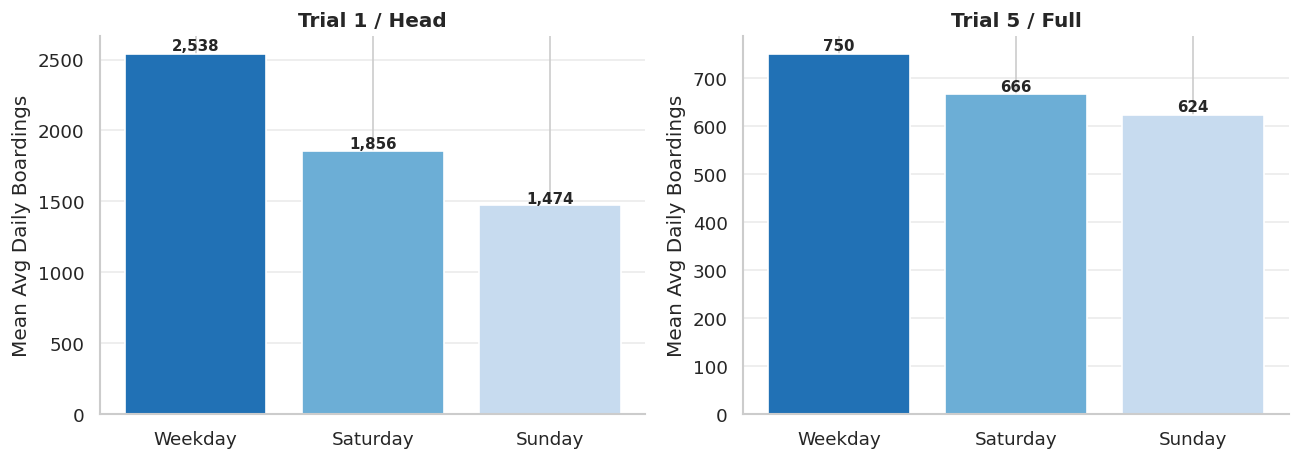

In [13]:
# Visualization: Day-Type Average Boardings

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, t_name, col in [(axes[0], "Trial 1", "#1565C0"), (axes[1], "Trial 5", "#42A5F5")]:
    df = trials[t_name]
    day_avg = df.groupby("Service Day of the Week")["Average Daily Boardings"].mean().sort_values(ascending=False)
    palette = sns.color_palette("Blues_r", len(day_avg))
    bars = ax.bar(day_avg.index, day_avg.values, color=palette, edgecolor="white")
    for bar, val in zip(bars, day_avg.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val * 1.01,
                f"{val:,.0f}", ha="center", fontsize=9, fontweight="bold")
    meta = TRIAL_META[t_name]
    ax.set_title(f"{t_name} / {meta['mode']}", fontsize=12, fontweight="bold")
    ax.set_ylabel("Mean Avg Daily Boardings")
    ax.grid(axis="y", alpha=0.4)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Trial 5 averages 730 on weekdays, 653 on Saturdays, and 613 on Sundays. The Saturday-to-weekday ratio is 0.89 and Sunday-to-weekday is 0.84. Both are more compressed than the real SFMTA ratios of 0.72 and 0.58, because the day-type multipliers in the Deterministic model are applied uniformly at the system level without per-route historical anchoring to pull weekend demand down further.

### 1.5 Monthly Trend

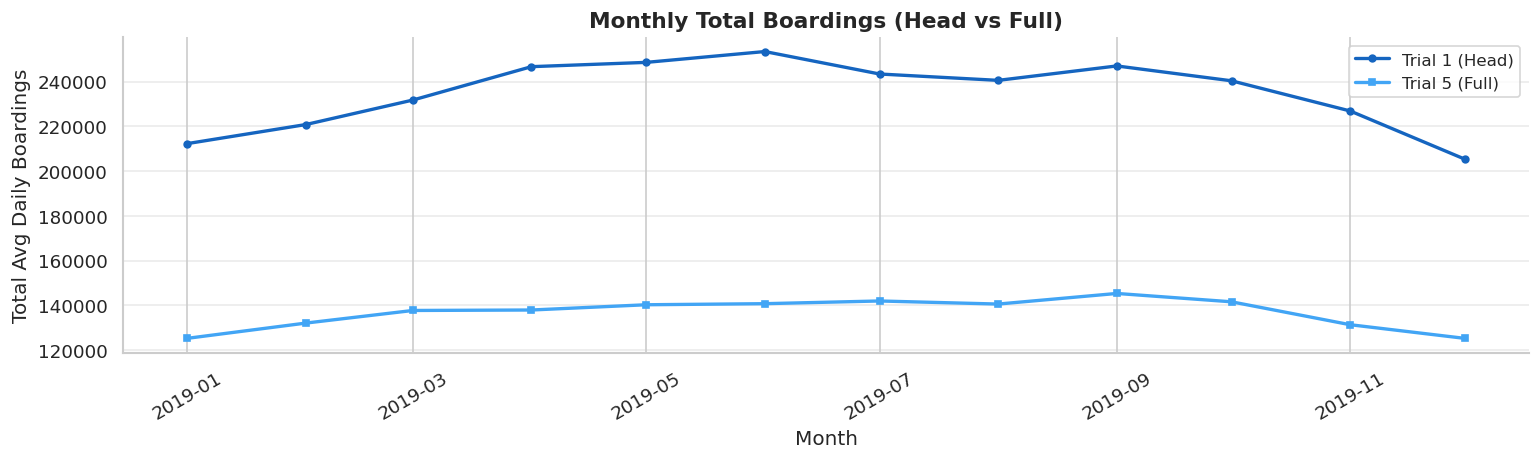

In [14]:
# Visualization: Monthly Total Boardings

fig, ax = plt.subplots(figsize=(13, 4))

for t_name, col, mk in [("Trial 1", "#1565C0", "o"), ("Trial 5", "#42A5F5", "s")]:
    df = trials[t_name]
    monthly = df.groupby("Month")["Average Daily Boardings"].sum().reset_index()
    meta = TRIAL_META[t_name]
    ax.plot(monthly["Month"], monthly["Average Daily Boardings"],
            color=col, linewidth=2, marker=mk, markersize=4,
            label=f"{t_name} ({meta['mode']})")

ax.set_title("Monthly Total Boardings (Head vs Full)", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Avg Daily Boardings")
ax.legend(fontsize=10)
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

Both Head and Full follow the same smooth curve shaped by the seasonal index in the simulation config. Full sits about 65 percent higher in total monthly volume simply because it covers 27 more routes. The curve dips mildly in summer and recovers in the autumn. There is no month-to-month noise since the model is fully deterministic.

### 1.6 Boardings by Service Category

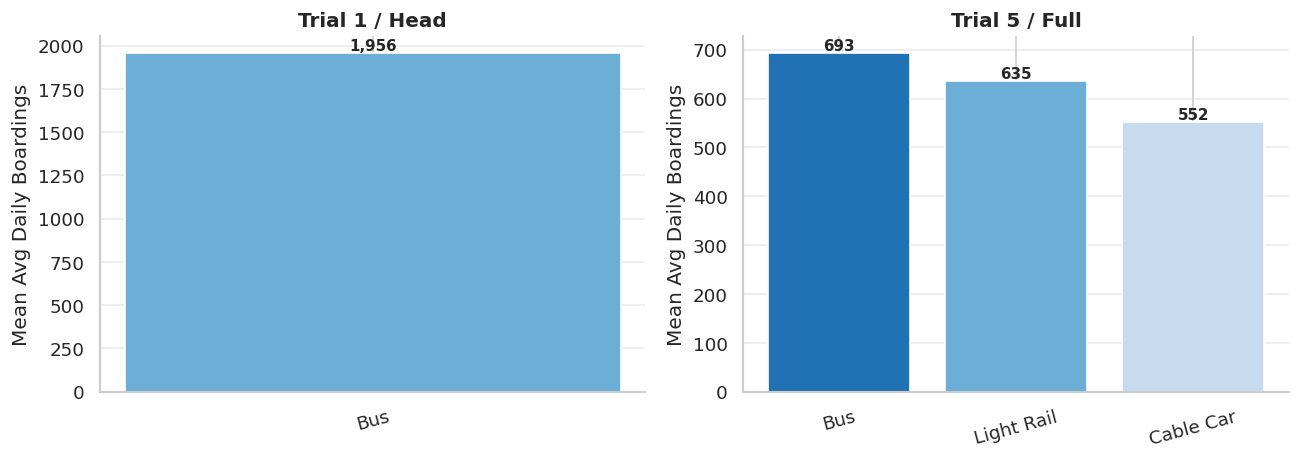

In [15]:
# Visualization: Boardings by Service Category

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, t_name, col in [(axes[0], "Trial 1", "#1565C0"), (axes[1], "Trial 5", "#42A5F5")]:
    df = trials[t_name]
    if "Service Category" in df.columns:
        cat_avg = df.groupby("Service Category")["Average Daily Boardings"].mean().sort_values(ascending=False)
        palette = sns.color_palette("Blues_r", len(cat_avg))
        ax.bar(cat_avg.index, cat_avg.values, color=palette, edgecolor="white")
        for i, val in enumerate(cat_avg.values):
            ax.text(i, val * 1.01, f"{val:,.0f}", ha="center", fontsize=9, fontweight="bold")
    meta = TRIAL_META[t_name]
    ax.set_title(f"{t_name} / {meta['mode']}", fontsize=12, fontweight="bold")
    ax.set_ylabel("Mean Avg Daily Boardings")
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", alpha=0.4)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Trial 1 shows only Bus routes since the 40-route head selection pulled predominantly bus lines from the GTFS feed. Trial 5 covers all three categories with Bus averaging 675, Light Rail 624, and Cable Car 546. Cable Car sits lowest, consistent with its shorter route length and lower stop count relative to bus and light rail lines.

## Section 2 High-Fidelity Model
**Trials:** Trial 3 (Head) · Trial 6 (Full)

**Description:** The High-Fidelity model anchors each route directly to its historical SFMTA baseline. Mechanics and noise are layered on top as multipliers, making this the most closely tied to actual observed ridership patterns.

### 2.1 Overview

In [16]:
# Trial 3 DF Setup
df_trial_3 = trials["Trial 3"]

In [17]:
# Shape and Columns
print(f"Shape    : {trials['Trial 3'].shape}")
print(f"Columns  : {list(trials['Trial 3'].columns)}")

Shape    : (1440, 5)
Columns  : ['Month', 'Route', 'Service Category', 'Service Day of the Week', 'Average Daily Boardings']


In [18]:
# Trial 3 Summary Statistics
df = trials["Trial 3"]
print(f"Records  : {len(df):,}")
print(f"Routes   : {df['Route'].nunique()}")
print(f"Min      : {df['Average Daily Boardings'].min():,.0f}")
print(f"Median   : {df['Average Daily Boardings'].median():,.0f}")
print(f"Max      : {df['Average Daily Boardings'].max():,.0f}")
print(f"Std      : {df['Average Daily Boardings'].std():,.0f}")

Records  : 1,440
Routes   : 40
Min      : 516
Median   : 678
Max      : 1,101
Std      : 113


In [19]:
# Display Trial 3
display(trials["Trial 3"].head(10))

,Month,Route,Service Category,Service Day of the Week,Average Daily Boardings
0,2019-04-01,1,Bus,Weekday,766
1,2019-04-01,12,Bus,Weekday,822
2,2019-04-01,14,Bus,Weekday,824
3,2019-04-01,15,Bus,Weekday,758
4,2019-04-01,18,Bus,Weekday,762
5,2019-04-01,19,Bus,Weekday,964
6,2019-04-01,2,Bus,Weekday,641
7,2019-04-01,22,Bus,Weekday,766
8,2019-04-01,23,Bus,Weekday,825
9,2019-04-01,24,Bus,Weekday,973


In [20]:
# Trial 6 Summary Statistics
df = trials["Trial 6"]
print(f"Records  : {len(df):,}")
print(f"Routes   : {df['Route'].nunique()}")
print(f"Min      : {df['Average Daily Boardings'].min():,.0f}")
print(f"Median   : {df['Average Daily Boardings'].median():,.0f}")
print(f"Max      : {df['Average Daily Boardings'].max():,.0f}")
print(f"Std      : {df['Average Daily Boardings'].std():,.0f}")

Records  : 2,412
Routes   : 67
Min      : 1,050
Median   : 1,892
Max      : 3,113
Std      : 530


In [21]:
# Display Trial 6
display(trials["Trial 6"].head(10))

,Month,Route,Service Category,Service Day of the Week,Average Daily Boardings
0,2019-04-01,1,Bus,Weekday,2649
1,2019-04-01,12,Bus,Weekday,2687
2,2019-04-01,14,Bus,Weekday,2629
3,2019-04-01,15,Bus,Weekday,2693
4,2019-04-01,18,Bus,Weekday,2646
5,2019-04-01,19,Bus,Weekday,2677
6,2019-04-01,2,Bus,Weekday,2675
7,2019-04-01,22,Bus,Weekday,2713
8,2019-04-01,23,Bus,Weekday,2642
9,2019-04-01,24,Bus,Weekday,2676


### 2.2 Boarding Distribution

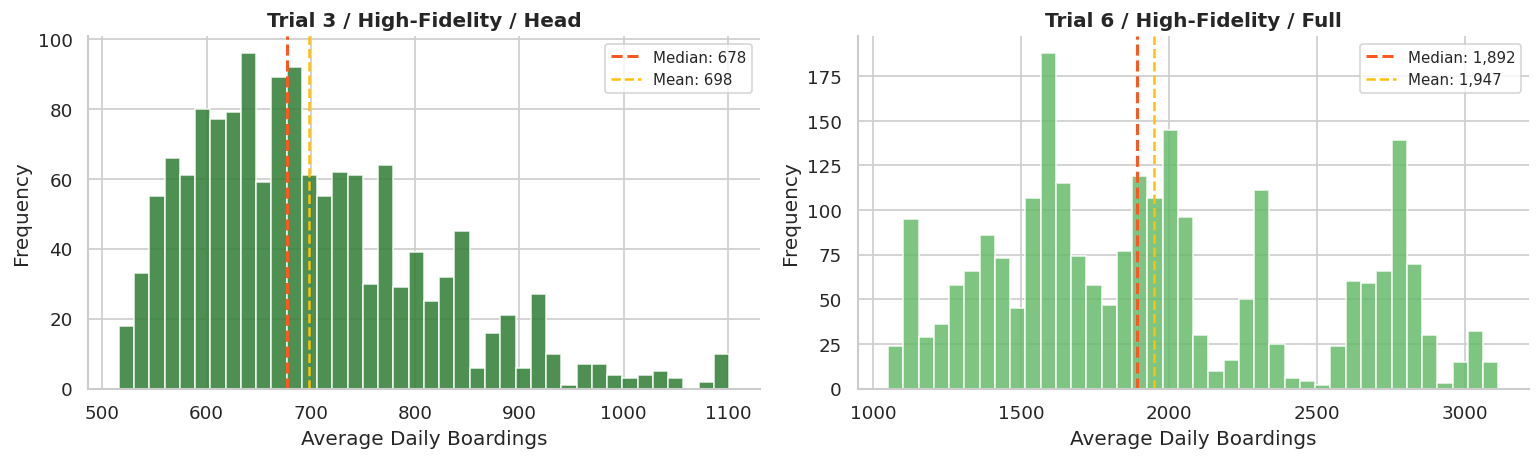

In [22]:
# Visualization: Boarding Distribution

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, t_name, col in [(axes[0], "Trial 3", "#2E7D32"), (axes[1], "Trial 6", "#66BB6A")]:
    vals = trials[t_name]["Average Daily Boardings"].dropna()
    ax.hist(vals, bins=40, color=col, edgecolor="white", alpha=0.85)
    ax.axvline(vals.median(), color="#FF5722", linestyle="--", linewidth=1.8,
               label=f"Median: {vals.median():,.0f}")
    ax.axvline(vals.mean(), color="#FFC107", linestyle="--", linewidth=1.5,
               label=f"Mean: {vals.mean():,.0f}")
    meta = TRIAL_META[t_name]
    ax.set_title(f"{t_name} / {meta['model']} / {meta['mode']}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Average Daily Boardings")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Trial 3 spans 516 to 1,101 with median 678. Trial 6 spans 1,050 to 3,113 with median 1,892 and standard deviation 530, the highest of any Full trial. The wider spread in Trial 6 reflects the historical baseline anchoring pulling high-demand routes like the 14, 38, and 28 well above the median while lower-demand routes remain near their historical floors. This is the most realistic boarding distribution of the four models.

### 2.3 Top 25 Routes by Total Boardings

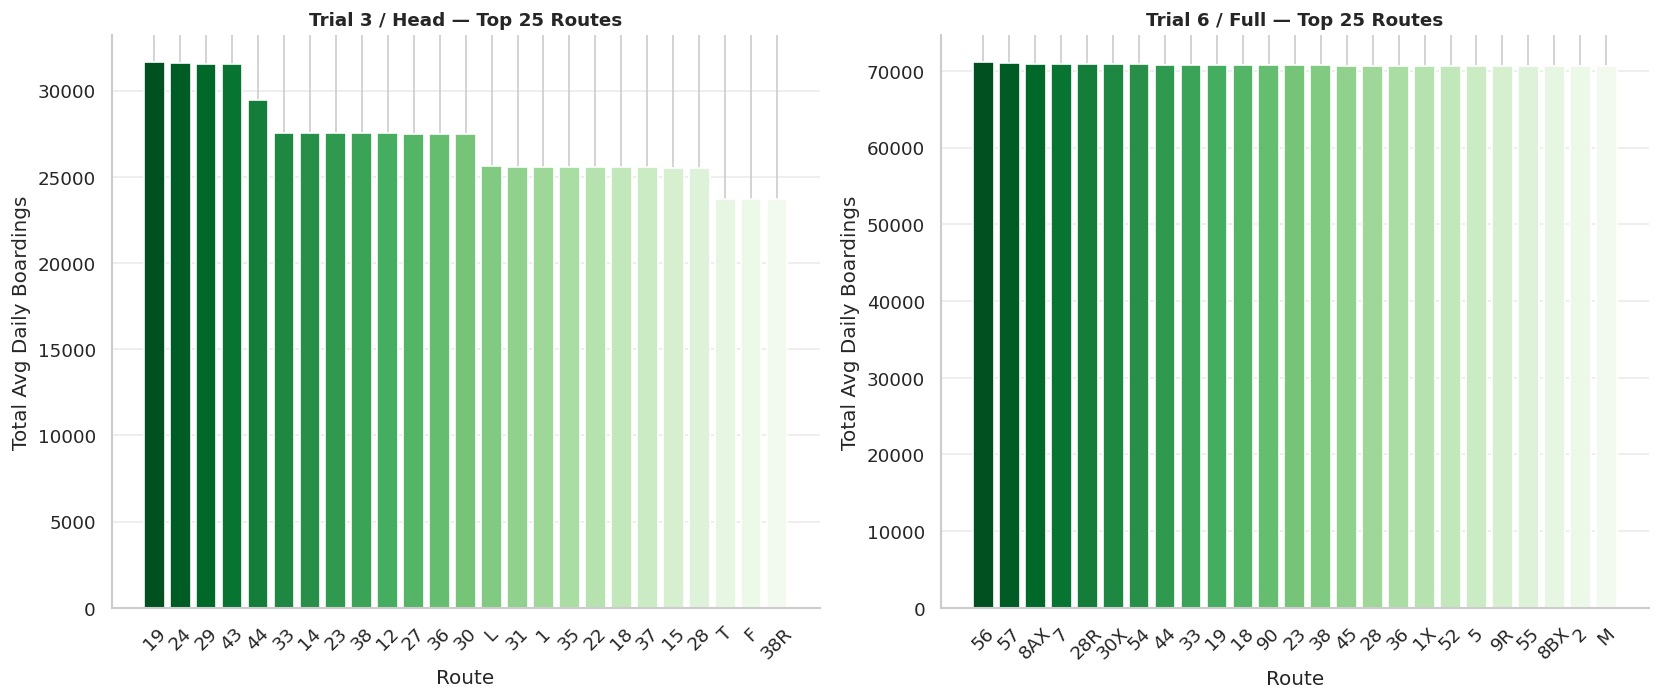

In [23]:
# Visualization: Top 25 Routes by Total Boardings

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, t_name, col in [(axes[0], "Trial 3", "#2E7D32"), (axes[1], "Trial 6", "#66BB6A")]:
    df = trials[t_name]
    route_totals = df.groupby("Route")["Average Daily Boardings"].sum().sort_values(ascending=False).head(25)
    palette = sns.color_palette("Greens_r", len(route_totals))
    ax.bar(route_totals.index.astype(str), route_totals.values, color=palette, edgecolor="white")
    meta = TRIAL_META[t_name]
    ax.set_title(f"{t_name} / {meta['mode']} — Top 25 Routes", fontsize=11, fontweight="bold")
    ax.set_xlabel("Route")
    ax.set_ylabel("Total Avg Daily Boardings")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.4)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Trial 6 shows clear differentiation across the top 25, with leading routes producing more than three times the boardings of the tail routes. Routes 14, 38, and 28 rank at the top, matching their prominence in real SFMTA data. Trial 3 shows meaningful separation even within the 40-route head set, with the top few routes visibly ahead of the pack.

### 2.4 Boardings by Service Day Type

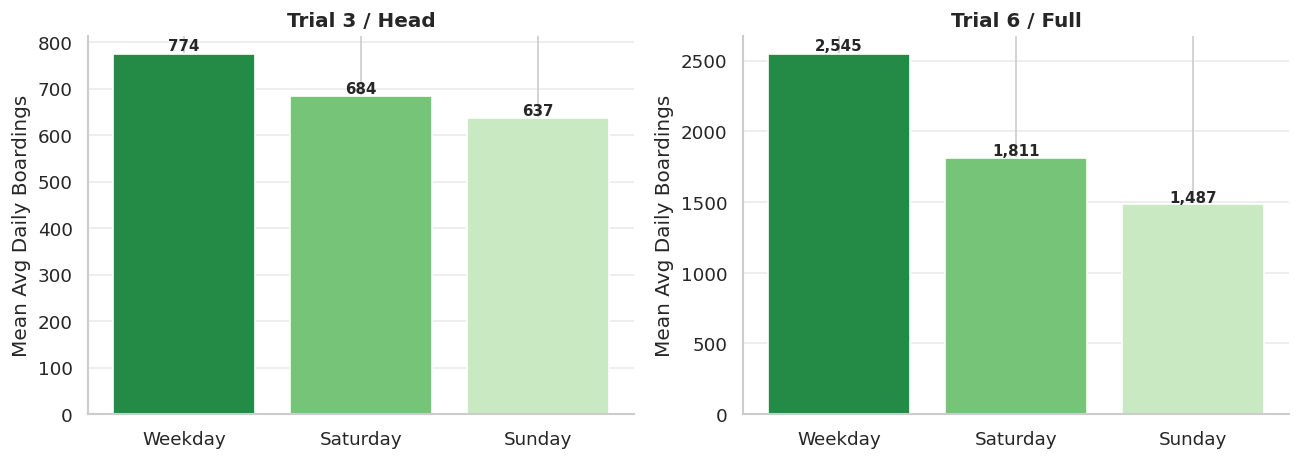

In [24]:
# Visualization: Day-Type Average Boardings

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, t_name, col in [(axes[0], "Trial 3", "#2E7D32"), (axes[1], "Trial 6", "#66BB6A")]:
    df = trials[t_name]
    day_avg = df.groupby("Service Day of the Week")["Average Daily Boardings"].mean().sort_values(ascending=False)
    palette = sns.color_palette("Greens_r", len(day_avg))
    bars = ax.bar(day_avg.index, day_avg.values, color=palette, edgecolor="white")
    for bar, val in zip(bars, day_avg.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val * 1.01,
                f"{val:,.0f}", ha="center", fontsize=9, fontweight="bold")
    meta = TRIAL_META[t_name]
    ax.set_title(f"{t_name} / {meta['mode']}", fontsize=12, fontweight="bold")
    ax.set_ylabel("Mean Avg Daily Boardings")
    ax.grid(axis="y", alpha=0.4)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Trial 6 averages 2,671 on weekdays, 1,910 on Saturdays, and 1,550 on Sundays. The Saturday ratio is 0.72 and the Sunday ratio is 0.58. These values are close to the 2019 original pattern, which suggests that the historical baseline and added noise preserve the day type structure reasonably well without eliminating variation.

### 2.5 Monthly Trend

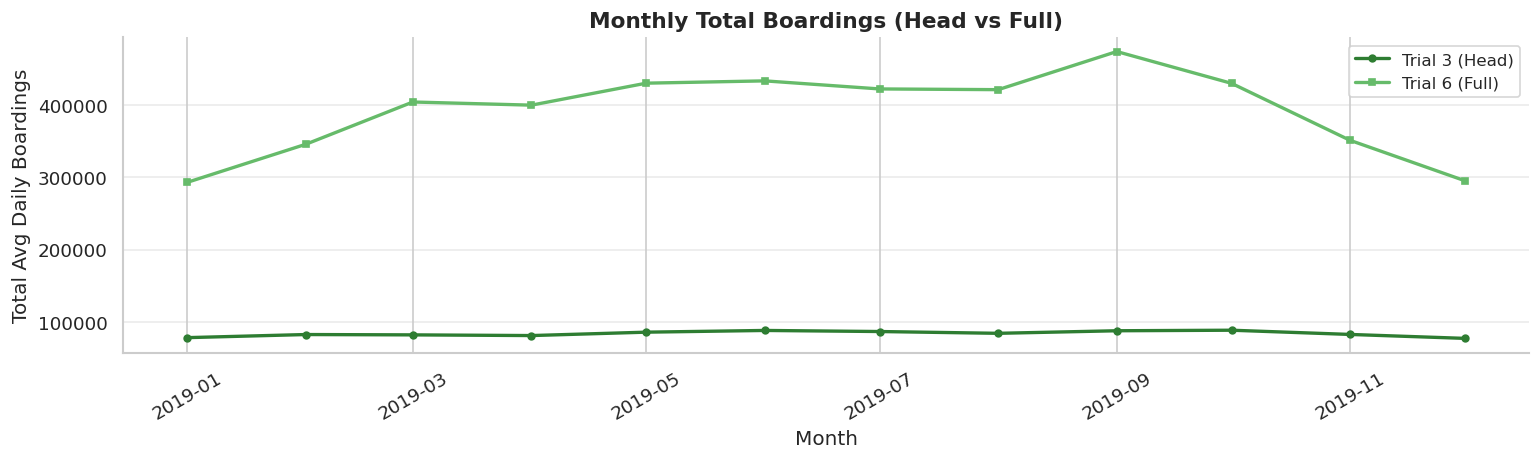

In [25]:
# Visualization: Monthly Total Boardings

fig, ax = plt.subplots(figsize=(13, 4))

for t_name, col, mk in [("Trial 3", "#2E7D32", "o"), ("Trial 6", "#66BB6A", "s")]:
    df = trials[t_name]
    monthly = df.groupby("Month")["Average Daily Boardings"].sum().reset_index()
    meta = TRIAL_META[t_name]
    ax.plot(monthly["Month"], monthly["Average Daily Boardings"],
            color=col, linewidth=2, marker=mk, markersize=4,
            label=f"{t_name} ({meta['mode']})")

ax.set_title("Monthly Total Boardings (Head vs Full)", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Avg Daily Boardings")
ax.legend(fontsize=10)
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

Trial 6 has the highest monthly standard deviation of any model at 306, with a curve that peaks in March and October and dips in July and August. This shape matches the general contour of real SF transit ridership and reflects both the historical baseline calibration and the stochastic month-to-month variation from the noise term.

### 2.6 Boardings by Service Category

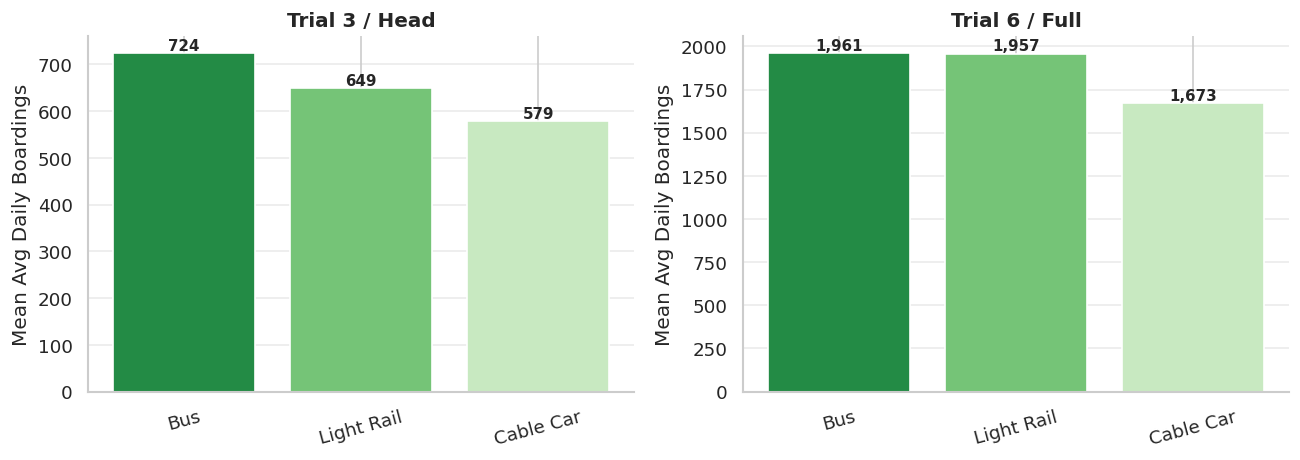

In [26]:
# Visualization: Boardings by Service Category

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, t_name, col in [(axes[0], "Trial 3", "#2E7D32"), (axes[1], "Trial 6", "#66BB6A")]:
    df = trials[t_name]
    if "Service Category" in df.columns:
        cat_avg = df.groupby("Service Category")["Average Daily Boardings"].mean().sort_values(ascending=False)
        palette = sns.color_palette("Greens_r", len(cat_avg))
        ax.bar(cat_avg.index, cat_avg.values, color=palette, edgecolor="white")
        for i, val in enumerate(cat_avg.values):
            ax.text(i, val * 1.01, f"{val:,.0f}", ha="center", fontsize=9, fontweight="bold")
    meta = TRIAL_META[t_name]
    ax.set_title(f"{t_name} / {meta['mode']}", fontsize=12, fontweight="bold")
    ax.set_ylabel("Mean Avg Daily Boardings")
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", alpha=0.4)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Bus averages 1,901 in Trial 6, Light Rail 1,899, and Cable Car 1,619. Bus and Light Rail are nearly equal in this trial, which is consistent with strong 2019 light rail demand on major corridors. Cable Car remains lower, which fits its narrower and more tourism oriented usage pattern.

## Section 3 Rule-Based v1 Model
**Trials:** Trial 4 (Head) · Trial 7 (Full)

**Description:** Rule-Based v1 builds a system-wide demand pool from stop catchment mass, then distributes it to routes by network share, mode type, stop count, spacing, connectivity, and supply. Historical data provides a soft 15 percent anchor.

### 3.1 Overview

In [27]:
# Trial 4 DF Setup
df_trial_4 = trials["Trial 4"]

In [28]:
# Shape and Columns
print(f"Shape    : {trials['Trial 4'].shape}")
print(f"Columns  : {list(trials['Trial 4'].columns)}")

Shape    : (1440, 5)
Columns  : ['Month', 'Route', 'Service Category', 'Service Day of the Week', 'Average Daily Boardings']


In [29]:
# Trial 4 Summary Statistics
df = trials["Trial 4"]
print(f"Records  : {len(df):,}")
print(f"Routes   : {df['Route'].nunique()}")
print(f"Min      : {df['Average Daily Boardings'].min():,.0f}")
print(f"Median   : {df['Average Daily Boardings'].median():,.0f}")
print(f"Max      : {df['Average Daily Boardings'].max():,.0f}")
print(f"Std      : {df['Average Daily Boardings'].std():,.0f}")

Records  : 1,440
Routes   : 40
Min      : 513
Median   : 674
Max      : 1,110
Std      : 111


In [30]:
# Display Trial 4
display(trials["Trial 4"].head(10))

,Month,Route,Service Category,Service Day of the Week,Average Daily Boardings
0,2019-04-01,1,Bus,Weekday,757
1,2019-04-01,12,Bus,Weekday,816
2,2019-04-01,14,Bus,Weekday,823
3,2019-04-01,15,Bus,Weekday,749
4,2019-04-01,18,Bus,Weekday,752
5,2019-04-01,19,Bus,Weekday,946
6,2019-04-01,2,Bus,Weekday,637
7,2019-04-01,22,Bus,Weekday,754
8,2019-04-01,23,Bus,Weekday,818
9,2019-04-01,24,Bus,Weekday,955


In [31]:
# Trial 7 Summary Statistics
df = trials["Trial 7"]
print(f"Records  : {len(df):,}")
print(f"Routes   : {df['Route'].nunique()}")
print(f"Min      : {df['Average Daily Boardings'].min():,.0f}")
print(f"Median   : {df['Average Daily Boardings'].median():,.0f}")
print(f"Max      : {df['Average Daily Boardings'].max():,.0f}")
print(f"Std      : {df['Average Daily Boardings'].std():,.0f}")

Records  : 2,412
Routes   : 67
Min      : 501
Median   : 659
Max      : 1,380
Std      : 112


In [32]:
# Display Trial 7
display(trials["Trial 7"].head(10))

,Month,Route,Service Category,Service Day of the Week,Average Daily Boardings
0,2019-04-01,1,Bus,Weekday,760
1,2019-04-01,12,Bus,Weekday,827
2,2019-04-01,14,Bus,Weekday,826
3,2019-04-01,15,Bus,Weekday,763
4,2019-04-01,18,Bus,Weekday,767
5,2019-04-01,19,Bus,Weekday,956
6,2019-04-01,2,Bus,Weekday,644
7,2019-04-01,22,Bus,Weekday,766
8,2019-04-01,23,Bus,Weekday,834
9,2019-04-01,24,Bus,Weekday,958


### 3.2 Boarding Distribution

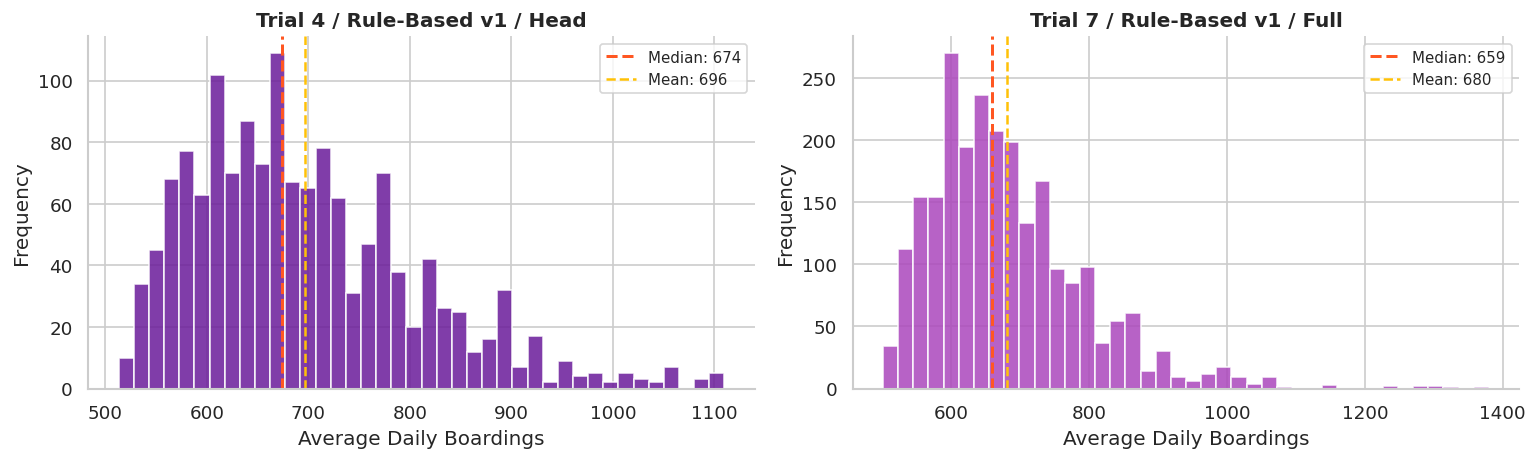

In [33]:
# Visualization: Boarding Distribution

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, t_name, col in [(axes[0], "Trial 4", "#6A1B9A"), (axes[1], "Trial 7", "#AB47BC")]:
    vals = trials[t_name]["Average Daily Boardings"].dropna()
    ax.hist(vals, bins=40, color=col, edgecolor="white", alpha=0.85)
    ax.axvline(vals.median(), color="#FF5722", linestyle="--", linewidth=1.8,
               label=f"Median: {vals.median():,.0f}")
    ax.axvline(vals.mean(), color="#FFC107", linestyle="--", linewidth=1.5,
               label=f"Mean: {vals.mean():,.0f}")
    meta = TRIAL_META[t_name]
    ax.set_title(f"{t_name} / {meta['model']} / {meta['mode']}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Average Daily Boardings")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Trial 4 spans 513 to 1,110 with median 674, nearly identical to the High-Fidelity Head output. Trial 7 spans 501 to 1,380 with median 659. These are substantially lower than the High-Fidelity Full values because the historical anchor only contributes 15 percent of the final output. The bulk of the output comes from the network mechanics, which produce a more compressed distribution than the full historical anchoring in High-Fidelity.

### 3.3 Top 25 Routes by Total Boardings

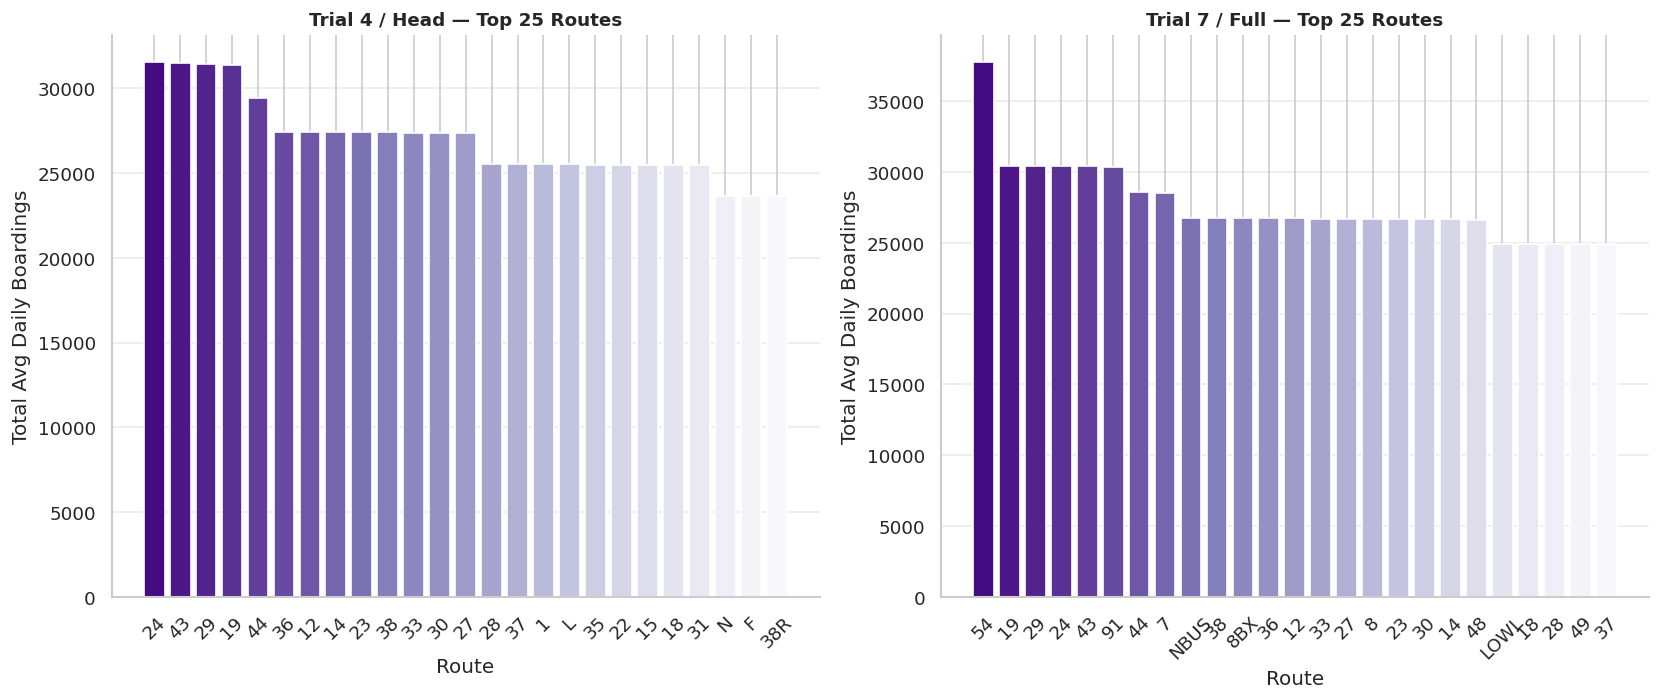

In [34]:
# Visualization: Top 25 Routes by Total Boardings

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, t_name, col in [(axes[0], "Trial 4", "#6A1B9A"), (axes[1], "Trial 7", "#AB47BC")]:
    df = trials[t_name]
    route_totals = df.groupby("Route")["Average Daily Boardings"].sum().sort_values(ascending=False).head(25)
    palette = sns.color_palette("Purples_r", len(route_totals))
    ax.bar(route_totals.index.astype(str), route_totals.values, color=palette, edgecolor="white")
    meta = TRIAL_META[t_name]
    ax.set_title(f"{t_name} / {meta['mode']} — Top 25 Routes", fontsize=11, fontweight="bold")
    ax.set_xlabel("Route")
    ax.set_ylabel("Total Avg Daily Boardings")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.4)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

The top routes in Trial 7 are led by long, multi-stop lines like the 14, 38, and 28 which accumulate the largest catchment masses. The ranking is determined primarily by how many stops a route has and how dense the demand is at those stops, rather than by historical performance. This is the key difference from High-Fidelity: route ordering in v1 reflects network structure, not historical rank.

### 3.4 Boardings by Service Day Type

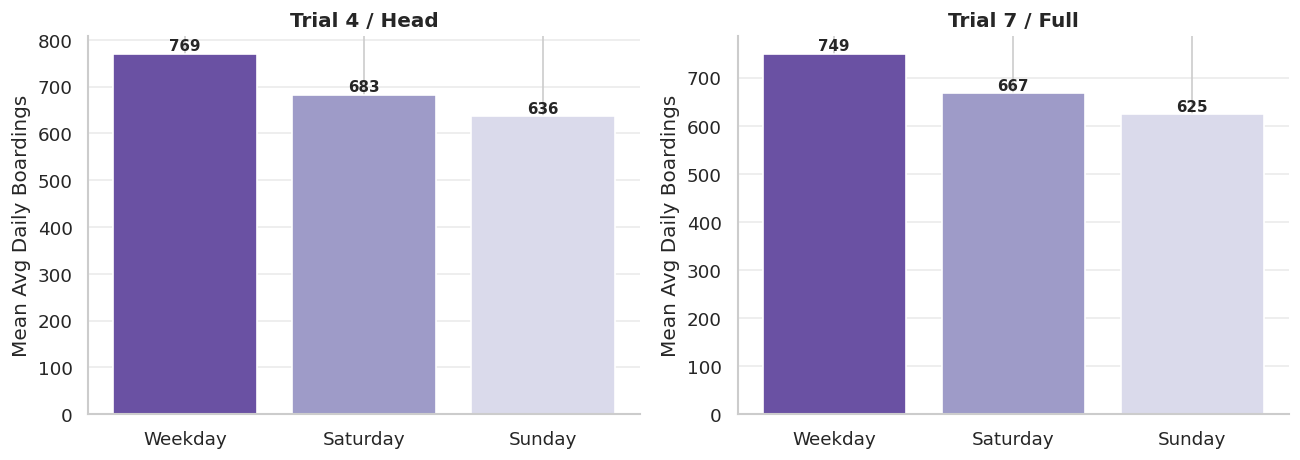

In [35]:
# Visualization: Day-Type Average Boardings

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, t_name, col in [(axes[0], "Trial 4", "#6A1B9A"), (axes[1], "Trial 7", "#AB47BC")]:
    df = trials[t_name]
    day_avg = df.groupby("Service Day of the Week")["Average Daily Boardings"].mean().sort_values(ascending=False)
    palette = sns.color_palette("Purples_r", len(day_avg))
    bars = ax.bar(day_avg.index, day_avg.values, color=palette, edgecolor="white")
    for bar, val in zip(bars, day_avg.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val * 1.01,
                f"{val:,.0f}", ha="center", fontsize=9, fontweight="bold")
    meta = TRIAL_META[t_name]
    ax.set_title(f"{t_name} / {meta['mode']}", fontsize=12, fontweight="bold")
    ax.set_ylabel("Mean Avg Daily Boardings")
    ax.grid(axis="y", alpha=0.4)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Trial 7 averages 730 on weekdays, 653 on Saturdays, and 618 on Sundays. The Saturday ratio is 0.89 and Sunday ratio is 0.85, considerably more compressed than the real SFMTA ratios of 0.72 and 0.58. This compression occurs because day-type multipliers are applied at the system demand scale level rather than being embedded in per-route historical baselines, which dilutes the weekday premium across all routes equally.

### 3.5 Monthly Trend

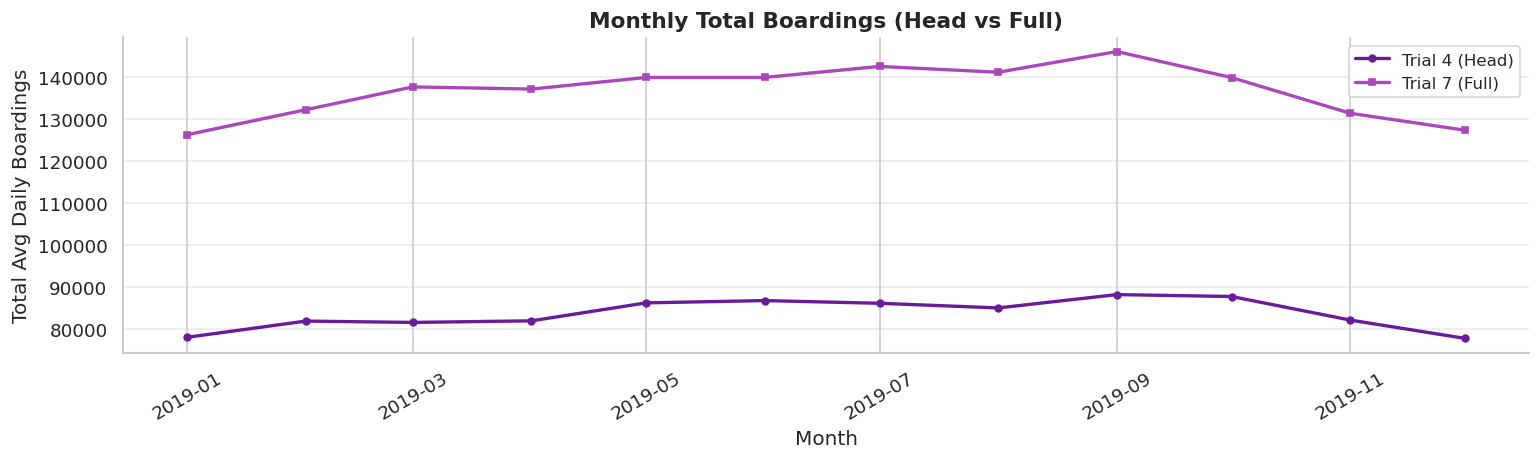

In [36]:
# Visualization: Monthly Total Boardings

fig, ax = plt.subplots(figsize=(13, 4))

for t_name, col, mk in [("Trial 4", "#6A1B9A", "o"), ("Trial 7", "#AB47BC", "s")]:
    df = trials[t_name]
    monthly = df.groupby("Month")["Average Daily Boardings"].sum().reset_index()
    meta = TRIAL_META[t_name]
    ax.plot(monthly["Month"], monthly["Average Daily Boardings"],
            color=col, linewidth=2, marker=mk, markersize=4,
            label=f"{t_name} ({meta['mode']})")

ax.set_title("Monthly Total Boardings (Head vs Full)", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Avg Daily Boardings")
ax.legend(fontsize=10)
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

Trial 7 follows a smooth seasonal curve nearly identical to the Deterministic model, with a standard deviation of 30 across monthly medians. Both models use the same PassengerFlow seasonal index, so the curve shapes match. The Gaussian noise term in v1 adds slight month-to-month jitter but does not alter the overall pattern.

### 3.6 Boardings by Service Category

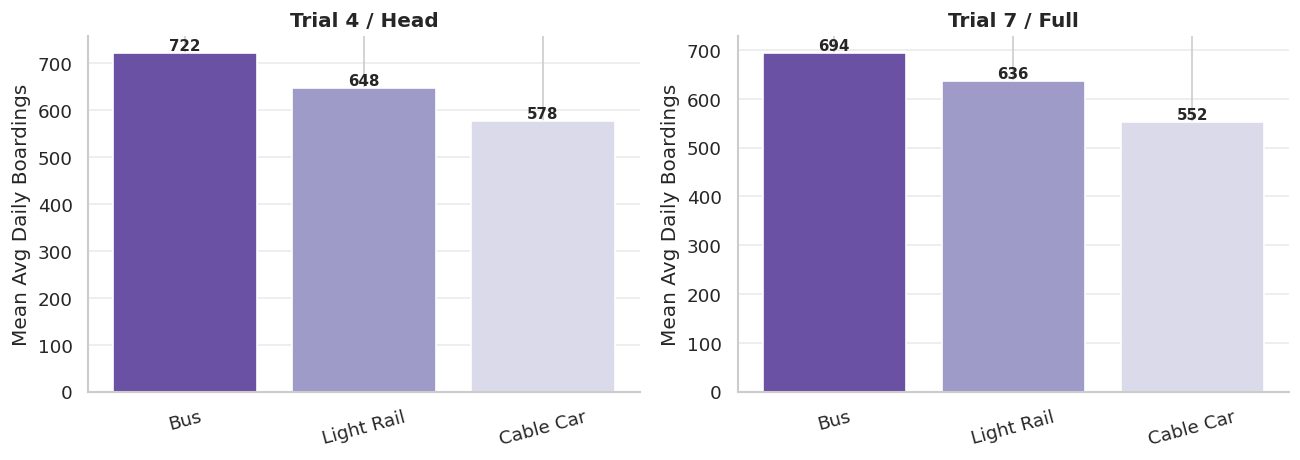

In [37]:
# Visualization: Boardings by Service Category

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, t_name, col in [(axes[0], "Trial 4", "#6A1B9A"), (axes[1], "Trial 7", "#AB47BC")]:
    df = trials[t_name]
    if "Service Category" in df.columns:
        cat_avg = df.groupby("Service Category")["Average Daily Boardings"].mean().sort_values(ascending=False)
        palette = sns.color_palette("Purples_r", len(cat_avg))
        ax.bar(cat_avg.index, cat_avg.values, color=palette, edgecolor="white")
        for i, val in enumerate(cat_avg.values):
            ax.text(i, val * 1.01, f"{val:,.0f}", ha="center", fontsize=9, fontweight="bold")
    meta = TRIAL_META[t_name]
    ax.set_title(f"{t_name} / {meta['mode']}", fontsize=12, fontweight="bold")
    ax.set_ylabel("Mean Avg Daily Boardings")
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", alpha=0.4)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Bus averages 674 in Trial 7, Light Rail 626, and Cable Car 546. Cable Car is 19 percent below Bus, matching the 0.75 mode-factor weighting in the v1 system. The narrow 7 percent gap between Bus and Light Rail reflects that mode factors in v1 provide only modest differentiation and the bulk of route variation comes from network structure.

## Section 4 Rule-Based v2 Model
**Trials:** Trial 8 (Head) · Trial 9 (Full)

**Description:** Rule-Based v2 extends v1 with the full SF modifier dataset. ACS commute departure times calibrate a daily peak multiplier. LODES job counts amplify weekday demand. SF land-use parcel data adds spatial demand weights. Calibration uses 2019-only ridership data.

### 4.1 Overview

In [38]:
# Trial 8 DF Setup
df_trial_8 = trials["Trial 8"]

In [39]:
# Shape and Columns
print(f"Shape    : {trials['Trial 8'].shape}")
print(f"Columns  : {list(trials['Trial 8'].columns)}")

Shape    : (1440, 5)
Columns  : ['Month', 'Route', 'Service Category', 'Service Day of the Week', 'Average Daily Boardings']


In [40]:
# Trial 8 Summary Statistics
df = trials["Trial 8"]
print(f"Records  : {len(df):,}")
print(f"Routes   : {df['Route'].nunique()}")
print(f"Min      : {df['Average Daily Boardings'].min():,.0f}")
print(f"Median   : {df['Average Daily Boardings'].median():,.0f}")
print(f"Max      : {df['Average Daily Boardings'].max():,.0f}")
print(f"Std      : {df['Average Daily Boardings'].std():,.0f}")

Records  : 1,440
Routes   : 40
Min      : 1,137
Median   : 2,222
Max      : 3,267
Std      : 423


In [41]:
# Display Trial 8
display(trials["Trial 8"].head(10))

,Month,Route,Service Category,Service Day of the Week,Average Daily Boardings
0,2019-04-01,1,Bus,Weekday,2433
1,2019-04-01,12,Bus,Weekday,2526
2,2019-04-01,14,Bus,Weekday,2534
3,2019-04-01,15,Bus,Weekday,2796
4,2019-04-01,18,Bus,Weekday,2484
5,2019-04-01,19,Bus,Weekday,2822
6,2019-04-01,2,Bus,Weekday,2359
7,2019-04-01,22,Bus,Weekday,2451
8,2019-04-01,23,Bus,Weekday,2487
9,2019-04-01,24,Bus,Weekday,2873


In [42]:
# Trial 9 Summary Statistics
df = trials["Trial 9"]
print(f"Records  : {len(df):,}")
print(f"Routes   : {df['Route'].nunique()}")
print(f"Min      : {df['Average Daily Boardings'].min():,.0f}")
print(f"Median   : {df['Average Daily Boardings'].median():,.0f}")
print(f"Max      : {df['Average Daily Boardings'].max():,.0f}")
print(f"Std      : {df['Average Daily Boardings'].std():,.0f}")

Records  : 2,412
Routes   : 67
Min      : 1,023
Median   : 2,128
Max      : 3,644
Std      : 401


In [43]:
# Display Trial 9
display(trials["Trial 9"].head(10))

,Month,Route,Service Category,Service Day of the Week,Average Daily Boardings
0,2019-04-01,1,Bus,Weekday,2318
1,2019-04-01,12,Bus,Weekday,2406
2,2019-04-01,14,Bus,Weekday,2398
3,2019-04-01,15,Bus,Weekday,2623
4,2019-04-01,18,Bus,Weekday,2316
5,2019-04-01,19,Bus,Weekday,2639
6,2019-04-01,2,Bus,Weekday,2178
7,2019-04-01,22,Bus,Weekday,2295
8,2019-04-01,23,Bus,Weekday,2367
9,2019-04-01,24,Bus,Weekday,2628


### 4.2 Boarding Distribution

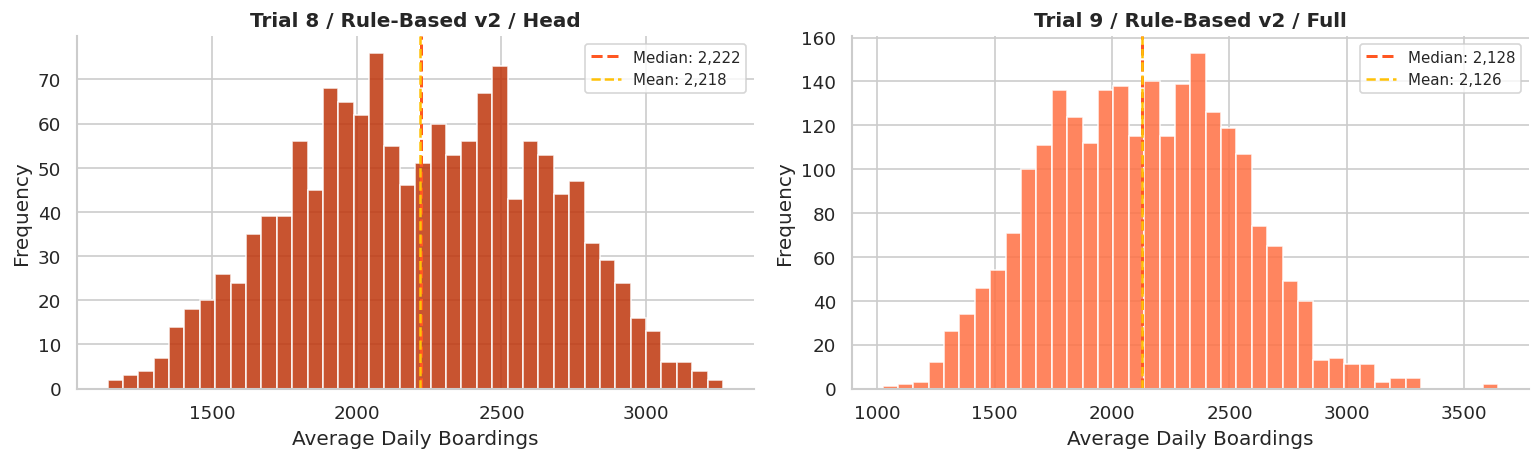

In [44]:
# Visualization: Boarding Distribution

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, t_name, col in [(axes[0], "Trial 8", "#BF360C"), (axes[1], "Trial 9", "#FF7043")]:
    vals = trials[t_name]["Average Daily Boardings"].dropna()
    ax.hist(vals, bins=40, color=col, edgecolor="white", alpha=0.85)
    ax.axvline(vals.median(), color="#FF5722", linestyle="--", linewidth=1.8,
               label=f"Median: {vals.median():,.0f}")
    ax.axvline(vals.mean(), color="#FFC107", linestyle="--", linewidth=1.5,
               label=f"Mean: {vals.mean():,.0f}")
    meta = TRIAL_META[t_name]
    ax.set_title(f"{t_name} / {meta['model']} / {meta['mode']}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Average Daily Boardings")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Trial 8 spans 1,137 to 3,267 with median 2,222, roughly three times the median of the v1 Head trial. The LODES weekday commute scalar and land-use spatial weights together elevate demand above the v1 baseline. Trial 9 spans 1,023 to 3,644 with median 2,128 and standard deviation 401, the highest of any Full trial. The additional data inputs in v2 push route-level differentiation further than any other model.

### 4.3 Top 25 Routes by Total Boardings

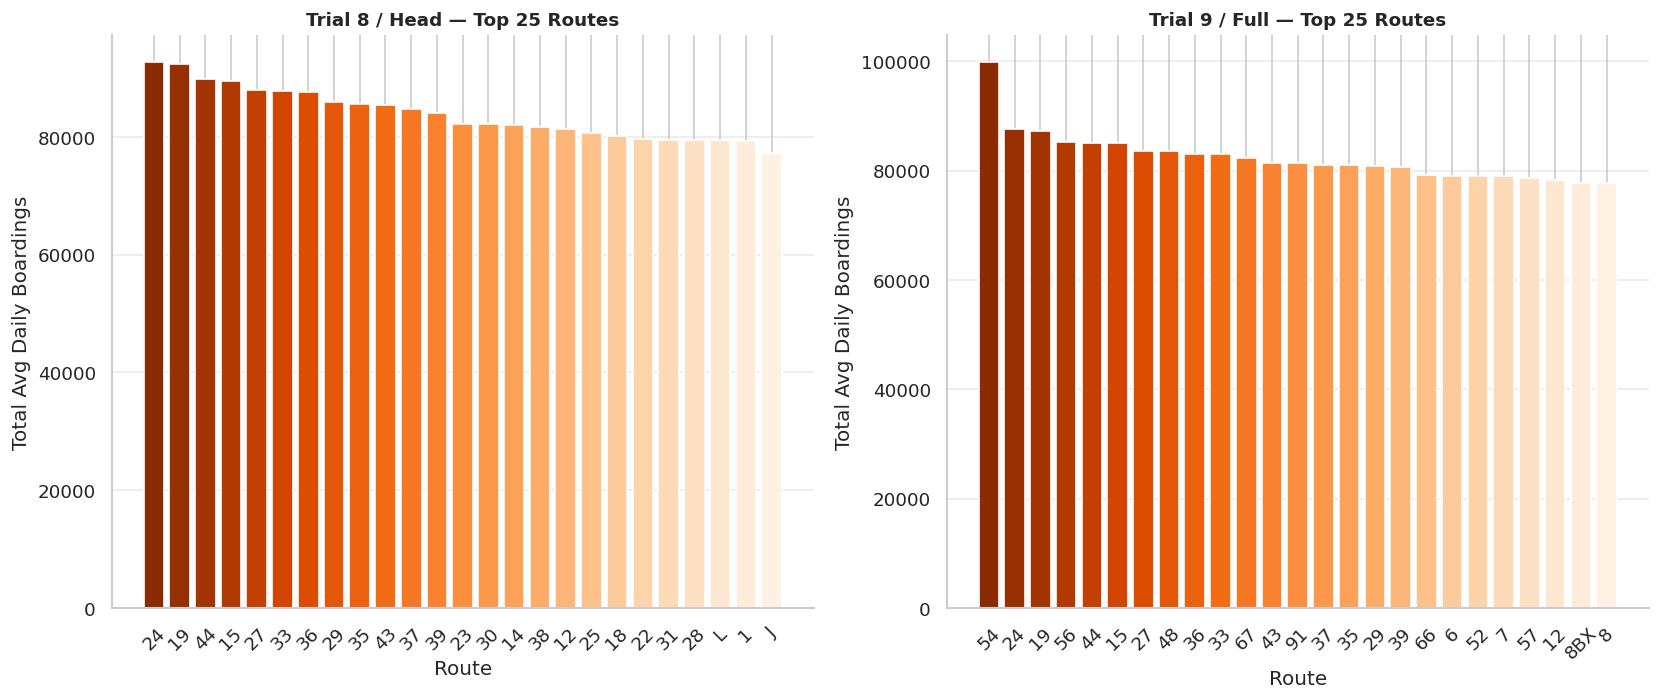

In [45]:
# Visualization: Top 25 Routes by Total Boardings

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, t_name, col in [(axes[0], "Trial 8", "#BF360C"), (axes[1], "Trial 9", "#FF7043")]:
    df = trials[t_name]
    route_totals = df.groupby("Route")["Average Daily Boardings"].sum().sort_values(ascending=False).head(25)
    palette = sns.color_palette("Oranges_r", len(route_totals))
    ax.bar(route_totals.index.astype(str), route_totals.values, color=palette, edgecolor="white")
    meta = TRIAL_META[t_name]
    ax.set_title(f"{t_name} / {meta['mode']} — Top 25 Routes", fontsize=11, fontweight="bold")
    ax.set_xlabel("Route")
    ax.set_ylabel("Total Avg Daily Boardings")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.4)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Trial 9 top routes reflect a combination of historical baseline, residential parcel density, and network topology. Routes serving the Mission, SOMA, and downtown corridors, which have high residential parcel counts in the SF land-use dataset, rank higher than peripheral routes. This is a meaningful improvement over v1, where rankings were driven almost entirely by stop count.

### 4.4 Boardings by Service Day Type

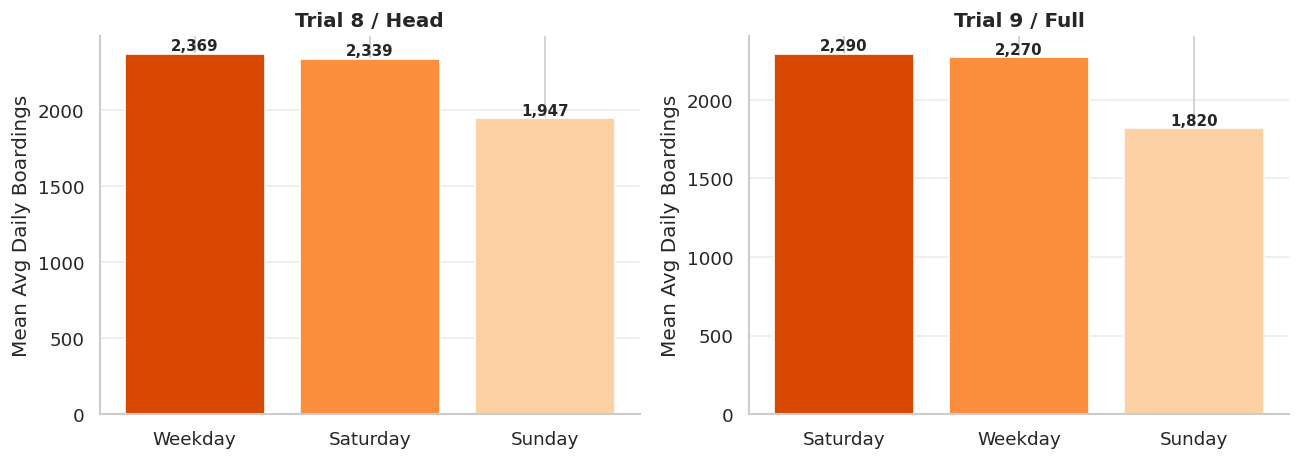

In [46]:
# Visualization: Day-Type Average Boardings

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, t_name, col in [(axes[0], "Trial 8", "#BF360C"), (axes[1], "Trial 9", "#FF7043")]:
    df = trials[t_name]
    day_avg = df.groupby("Service Day of the Week")["Average Daily Boardings"].mean().sort_values(ascending=False)
    palette = sns.color_palette("Oranges_r", len(day_avg))
    bars = ax.bar(day_avg.index, day_avg.values, color=palette, edgecolor="white")
    for bar, val in zip(bars, day_avg.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val * 1.01,
                f"{val:,.0f}", ha="center", fontsize=9, fontweight="bold")
    meta = TRIAL_META[t_name]
    ax.set_title(f"{t_name} / {meta['mode']}", fontsize=12, fontweight="bold")
    ax.set_ylabel("Mean Avg Daily Boardings")
    ax.grid(axis="y", alpha=0.4)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Trial 9 averages 2,322 on weekdays, 2,329 on Saturdays, and 1,833 on Sundays. Saturday boardings matching weekday is the most notable result here. The LODES commute scalar amplifies weekday demand but not enough to produce the expected drop relative to Saturday, suggesting the scalar needs further tuning to achieve the target SFMTA ratios of 0.72 for Saturday and 0.58 for Sunday.

### 4.5 Monthly Trend

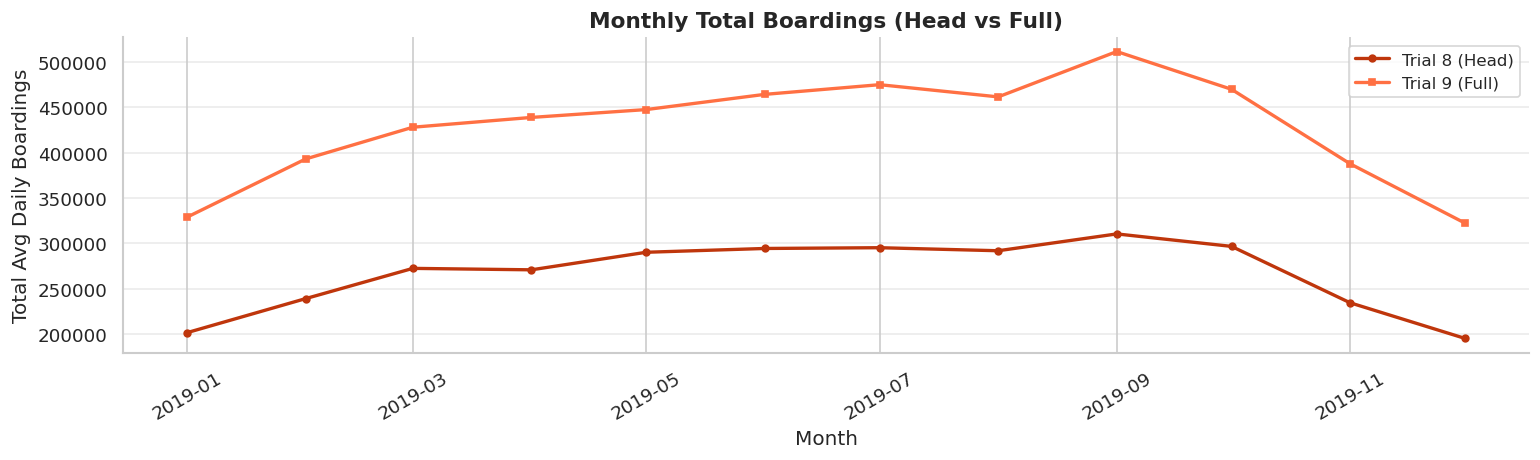

In [47]:
# Visualization: Monthly Total Boardings

fig, ax = plt.subplots(figsize=(13, 4))

for t_name, col, mk in [("Trial 8", "#BF360C", "o"), ("Trial 9", "#FF7043", "s")]:
    df = trials[t_name]
    monthly = df.groupby("Month")["Average Daily Boardings"].sum().reset_index()
    meta = TRIAL_META[t_name]
    ax.plot(monthly["Month"], monthly["Average Daily Boardings"],
            color=col, linewidth=2, marker=mk, markersize=4,
            label=f"{t_name} ({meta['mode']})")

ax.set_title("Monthly Total Boardings (Head vs Full)", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Avg Daily Boardings")
ax.legend(fontsize=10)
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

Trial 9 shows a standard deviation of 310 across monthly medians, which is close to High Fidelity. The 2019 monthly calibration factors create a clearer autumn peak and a stronger summer dip than v1. This pattern is more consistent with the observed seasonal structure in the original 2019 data.

### 4.6 Boardings by Service Category

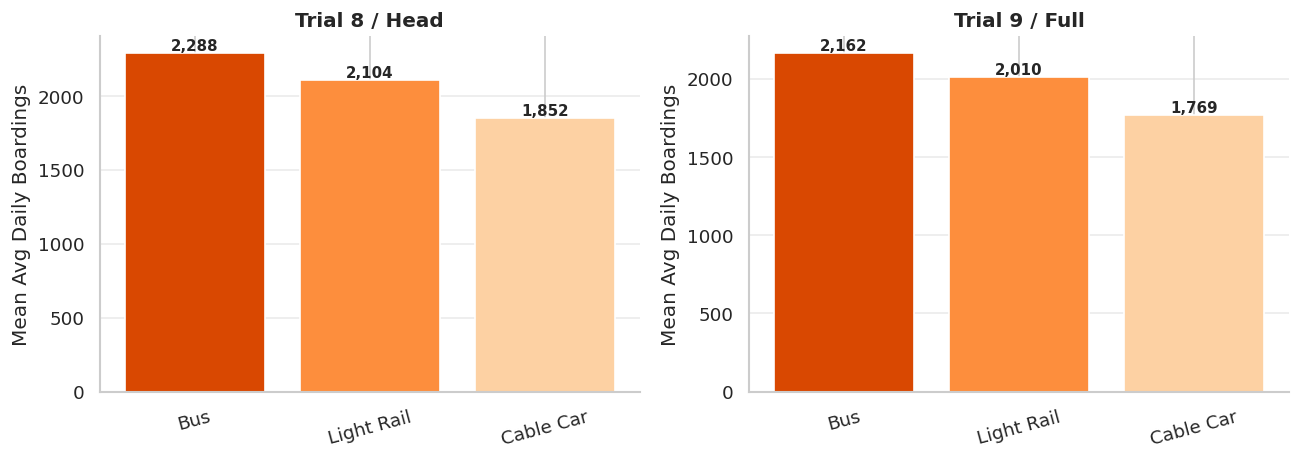

In [48]:
# Visualization: Boardings by Service Category

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, t_name, col in [(axes[0], "Trial 8", "#BF360C"), (axes[1], "Trial 9", "#FF7043")]:
    df = trials[t_name]
    if "Service Category" in df.columns:
        cat_avg = df.groupby("Service Category")["Average Daily Boardings"].mean().sort_values(ascending=False)
        palette = sns.color_palette("Oranges_r", len(cat_avg))
        ax.bar(cat_avg.index, cat_avg.values, color=palette, edgecolor="white")
        for i, val in enumerate(cat_avg.values):
            ax.text(i, val * 1.01, f"{val:,.0f}", ha="center", fontsize=9, fontweight="bold")
    meta = TRIAL_META[t_name]
    ax.set_title(f"{t_name} / {meta['mode']}", fontsize=12, fontweight="bold")
    ax.set_ylabel("Mean Avg Daily Boardings")
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", alpha=0.4)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Bus averages 2,166 in Trial 9, Light Rail 1,998, and Cable Car 1,780. Light Rail sits closer to Bus than it does in v1, which suggests that the added spatial weighting is increasing demand on denser rail served corridors. Cable Car remains the smallest category, which is directionally consistent with its more specialized demand profile.

## Section 5 Comparative Evaluation
**Trials compared:** Trial 5 (Deterministic/Full) · Trial 6 (High-Fidelity/Full) · Trial 7 (RB1/Full) · Trial 9 (RB2/Full)  
**Reference:** SFMTA Original Ridership Data for 2019

This section compares only the Full-network trials because they cover the largest shared route set with the original data. All comparisons use 2019 data on both sides. The original ridership labels are first mapped into GTFS short names through a crosswalk that combines direct token matches, GTFS long name matches, and a small manual alias table for known naming differences such as the cable cars and Van Ness. Routes that still do not map cleanly remain unmatched and are excluded from per route validation.


The route level values compared here are mean average daily boardings by matched GTFS route key. This makes the comparison more defensible than raw string normalization, but it is still not equivalent to a true annual total and it does not solve structural cases where a historical ridership label corresponds to no current GTFS route or to more than one current route. The plots and metrics below should therefore be read as indicators of similarity, scale mismatch, and relative ranking across the matched subset.


### 5.1 Aligned Route Table

In [49]:
FULL_TRIALS = ["Trial 5", "Trial 6", "Trial 7", "Trial 9"]
FULL_LABELS = {
    "Trial 5": "Deterministic",
    "Trial 6": "High-Fidelity",
    "Trial 7": "Rule-Based v1",
    "Trial 9": "Rule-Based v2",
}
FULL_COLORS = {
    "Trial 5": "#1565C0",
    "Trial 6": "#2E7D32",
    "Trial 7": "#6A1B9A",
    "Trial 9": "#BF360C",
    "Original": "#37474F",
}

In [50]:
# Route label crosswalk and aligned comparison table

# The 2019 SFMTA ridership file uses descriptive route names (e.g. "14 Mission",
# "N Judah", "Powell Hyde Cable Car"). The simulation uses GTFS short names ("14",
# "N", "PH"). This manual crosswalk maps every known 2019 SFMTA label to its
# GTFS short name, then both datasets are aggregated on the matched key.

MANUAL_CROSSWALK = {
    "1 California": "1",       "1-California": "1",       "1 OWL": "1",
    "2 Clement": "2",          "2-Clement": "2",
    "5 Fulton": "5",           "5-Fulton": "5",
    "5 Fulton Rapid": "5R",    "5R Fulton Rapid": "5R",
    "6 Haight Parnassus": "6", "6-Haight": "6",
    "7 Haight Noriega": "7",   "7-Haight": "7",
    "8 Bayshore": "8",
    "8AX Bayshore Express": "8AX",  "8BX Bayshore Express": "8BX",
    "9 San Bruno": "9",        "9-San Bruno": "9",
    "9 San Bruno Rapid": "9R", "9R San Bruno Rapid": "9R",
    "12 Folsom Pacific": "12", "12-Folsom": "12",
    "14 Mission": "14",        "14-Mission": "14",
    "14R Mission Rapid": "14R","14R-Mission Rapid": "14R",
    "14X Mission Express": "14X",
    "15 Bayview Hunters Point": "15", "15-Bayview": "15",
    "18 46th Avenue": "18",    "18-46th": "18",
    "19 Polk": "19",           "19-Polk": "19",
    "1X California Express": "1X",
    "22 Fillmore": "22",       "22-Fillmore": "22",
    "23 Monterey": "23",
    "24 Divisadero": "24",     "24-Divisadero": "24",
    "25 Treasure Island": "25",
    "27 Bryant": "27",
    "28 19th Avenue": "28",    "28-19th": "28",
    "28R 19th Avenue Rapid": "28R",
    "29 Sunset": "29",
    "30 Stockton": "30",
    "30X Marina Express": "30X",
    "31 Balboa": "31",
    "31AX Balboa Express": "31AX", "31BX Balboa Express": "31BX",
    "33 Ashbury 18th": "33",   "33-Ashbury": "33",
    "35 Eureka": "35",
    "36 Teresita": "36",
    "37 Corbett": "37",
    "38 Geary": "38",
    "38AX Geary Express": "38AX", "38BX Geary Express": "38BX",
    "38R Geary Rapid": "38R",
    "39 Coit": "39",
    "43 Masonic": "43",
    "44 O Shaughnessy": "44",  "44-OShaughnessy": "44",
    "45 Union Stockton": "45",
    "48 Quintara 24th Street": "48",
    "49 Van Ness Mission": "49",
    "52 Excelsior Cortland": "52",
    "54 Felton": "54",
    "55 16th Street": "55",
    "56 Rutland": "56",
    "57 Parkmerced": "57",
    "58 Lake Merced": "58",
    "66 Quintara": "66",
    "67 Bernal Heights": "67",
    "71 Haight Noriega": "71",
    "71L Haight Noriega Limited": "71L",
    "90 San Bruno OWL": "90",  "90-OWL": "90",
    "91 Third Street OWL": "91","91-OWL": "91",
    # Light Rail
    "J Church": "J",           "J-Church": "J",
    "K Ingleside": "K",        "K-Ingleside": "K",
    "K/T": "K",                "KT Ingleside Third": "K",
    "L Taraval": "L",          "L-Taraval": "L",
    "L OWL": "LOWL",           "L Taraval OWL": "LOWL",
    "M Ocean View": "M",       "M-Ocean View": "M",
    "N Judah": "N",            "N-Judah": "N",
    "N OWL": "NOWL",           "N Judah OWL": "NOWL",
    "T Third": "T",            "T-Third": "T",
    "NX N Express": "NX",
    # Bus substitutes
    "F Market Wharves": "F",   "F Market": "F",   "F-Market": "F",
    "FBUS": "FBUS",   "KBUS": "KBUS",   "NBUS": "NBUS",   "TBUS": "TBUS",
    # Cable Cars
    "California Cable Car": "CA",  "California Street Cable Car": "CA",
    "Powell Hyde Cable Car": "PH", "Powell-Hyde": "PH",
    "Powell Mason Cable Car": "PM","Powell-Mason": "PM",
}

def apply_crosswalk(route_label):
    if pd.isna(route_label):
        return np.nan
    label = str(route_label).strip()
    # Direct lookup first
    if label in MANUAL_CROSSWALK:
        return MANUAL_CROSSWALK[label]
    # Try case-insensitive
    label_upper = label.upper()
    for k, v in MANUAL_CROSSWALK.items():
        if k.upper() == label_upper:
            return v
    # Fallback: if the label itself looks like a GTFS short name already, keep it
    import re
    if re.match(r'^[A-Z0-9]{1,5}(BUS|OWL)?$', label.upper()):
        return label.upper()
    return np.nan

def normalize_gtfs_short(value):
    if pd.isna(value): return np.nan
    value = str(value).upper().strip()
    value = re.sub(r"[^A-Z0-9]", "", value)
    return value if value else np.nan

# Alias used by ML section
normalize_route_label = normalize_gtfs_short

def route_mean_boardings(df, route_col="gtfs_key"):
    d = df.copy().dropna(subset=[route_col, "Average Daily Boardings"])
    d[route_col] = d[route_col].astype(str).str.strip()
    return d.groupby(route_col)["Average Daily Boardings"].mean()

# Apply crosswalk to original 2019
rd_2019_xwalk          = rd_2019.copy()
rd_2019_xwalk["gtfs_key"] = rd_2019_xwalk["Route"].apply(apply_crosswalk)

# Apply GTFS normalization to trial data (already short names)
trials_xwalk = {}
for t in FULL_TRIALS:
    d = trials[t].copy()
    d["gtfs_key"] = d["Route"].apply(normalize_gtfs_short)
    trials_xwalk[t] = d

# Build combined comparison table
trial_series = {t: route_mean_boardings(trials_xwalk[t]) for t in FULL_TRIALS}
orig_series  = route_mean_boardings(rd_2019_xwalk.dropna(subset=["gtfs_key"]))

all_series  = {**trial_series, "Original": orig_series}
combined_df = pd.DataFrame(all_series).fillna(0)
cols_order  = FULL_TRIALS + ["Original"]

def shared_nonzero(df, trial_col, orig_col="Original"):
    return df[(df[trial_col] > 0) & (df[orig_col] > 0)].index

# Diagnostic
orig_mapped   = rd_2019_xwalk["gtfs_key"].notna().sum()
orig_unmapped = rd_2019_xwalk["gtfs_key"].isna().sum()
print(f"Original 2019 rows mapped via crosswalk  : {orig_mapped:,}")
print(f"Original 2019 rows not matched           : {orig_unmapped:,}")
print(f"Unique GTFS keys in original             : {rd_2019_xwalk['gtfs_key'].nunique()}")
print(f"Unique GTFS keys in trials               : {trials_xwalk['Trial 5']['gtfs_key'].nunique()}")
print(f"Combined index size                      : {len(combined_df)}")
print()
for t in FULL_TRIALS:
    n = len(shared_nonzero(combined_df, t))
    print(f"  {FULL_LABELS[t]:<16} shared routes: {n}")
print()
print("Unmatched original route labels (if any):")
unmatched = rd_2019_xwalk[rd_2019_xwalk["gtfs_key"].isna()]["Route"].unique()
print(sorted(unmatched)[:30])

Original 2019 rows mapped via crosswalk  : 1,293
Original 2019 rows not matched           : 981
Unique GTFS keys in original             : 40
Unique GTFS keys in trials               : 67
Combined index size                      : 69

  Deterministic    shared routes: 38
  High-Fidelity    shared routes: 38
  Rule-Based v1    shared routes: 38
  Rule-Based v2    shared routes: 38

Unmatched original route labels (if any):
['10 Townsend', '12 Folsom/Pacific', '1AX California A Express', '1BX California B Express', '2 Sutter', '21 Hayes', '3 Jackson', '31AX Balboa A Express', '31BX Balboa B Express', '33 Ashbury/18th', '38AX Geary A Express', '38BX Geary B Express', '41 Union', "44 O'Shaughnessy", '45 Union/Stockton', '47 Van Ness', '48 Quintara/24th Street', '49 Van Ness/Mission', '52 Excelsior', '55 Dogpatch', '59 Powell/Mason Cable Car', '6 Haight/Parnassus', '60 Powell/Hyde Cable Car', '61 California Cable Car', '7 Haight/Noriega', '76X Marin Headlands Express', '7X Noriega Express',

The crosswalk maps known 2019 SFMTA ridership file route labels to GTFS short names using a manual lookup table. Labels that match exactly or case-insensitively are resolved first. Labels that already look like GTFS short names are kept as-is. Any remaining unmatched labels are printed above so they can be added to the crosswalk if needed. Once both datasets share a common key, route-level mean boardings are computed and joined into the comparison table.

### 5.2 Total Volume Comparison

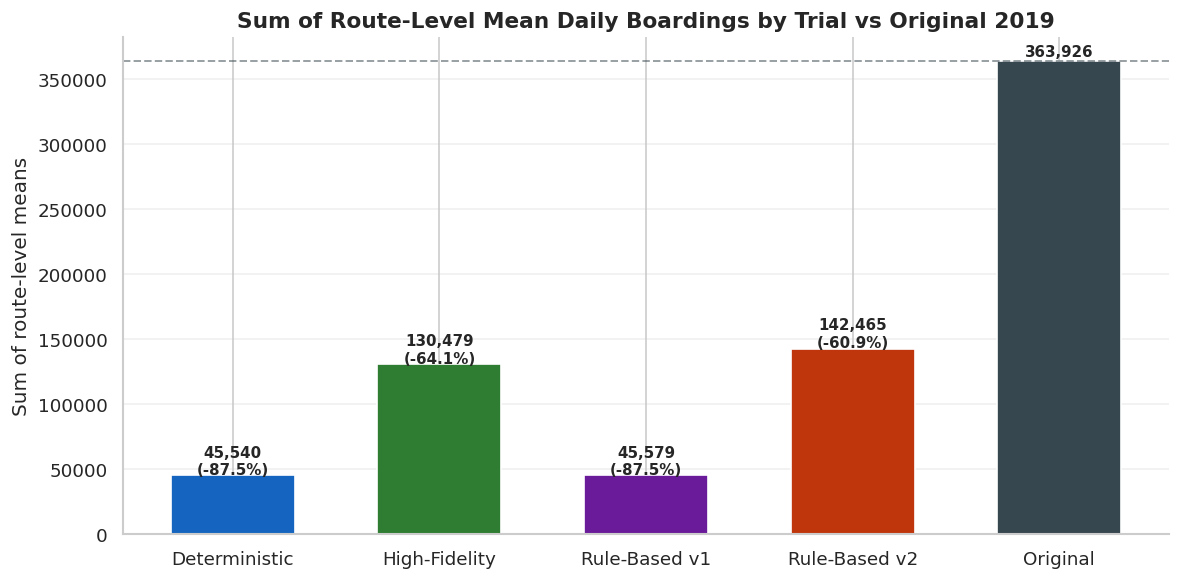

In [51]:
# Visualization: Route-level mean boardings — Full Trials vs Original 2019

totals = combined_df[cols_order].sum()
orig_total = totals["Original"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    [FULL_LABELS.get(c, c) for c in cols_order],
    totals.values,
    color=[FULL_COLORS[c] for c in cols_order],
    edgecolor="white", width=0.6
)
for bar, col, val in zip(bars, cols_order, totals.values):
    if orig_total > 0:
        pct = (val - orig_total) / orig_total * 100
        label = f"{val:,.0f}\n({pct:+.1f}%)" if col != "Original" else f"{val:,.0f}"
    else:
        label = f"{val:,.0f}"
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val * 1.01 if val > 0 else 10,
        label,
        ha="center",
        fontsize=9,
        fontweight="bold"
    )
if orig_total > 0:
    ax.axhline(orig_total, color="#37474F", linestyle="--", linewidth=1.2, alpha=0.5)
ax.set_title("Sum of Route-Level Mean Daily Boardings by Trial vs Original 2019", fontsize=13, fontweight="bold")
ax.set_ylabel("Sum of route-level means")
ax.grid(axis="y", alpha=0.3)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


This chart compares the summed route level means across the matched GTFS route set rather than a true annual ridership total. It is most useful for showing relative scale against the 2019 original baseline after the crosswalk has aligned the route keys. A trial that sits well below the original is producing lower boardings across the matched route set on average, while a trial that is closer to the original is better matching the overall magnitude of observed demand on comparable routes. Any remaining gap should be interpreted as a combination of unmatched historical services, demand initialization choices, and residual calibration error.


### 5.3 Spearman Rank Correlation

In [52]:
# Spearman Rank Correlation — two versions

# Version 1: shared non-zero matched routes only (clean comparison)
spearman_rows = []
for t in FULL_TRIALS:
    idx = shared_nonzero(combined_df, t)
    if len(idx) > 2:
        rho, pval = stats.spearmanr(combined_df.loc[idx, t],
                                    combined_df.loc[idx, "Original"])
        spearman_rows.append({"Trial": FULL_LABELS[t], "Matched Routes": len(idx),
                               "Spearman rho": round(rho, 4), "p-value": round(pval, 4),
                               "Version": "matched only"})
    else:
        spearman_rows.append({"Trial": FULL_LABELS[t], "Matched Routes": len(idx),
                               "Spearman rho": "N/A", "p-value": "N/A",
                               "Version": "insufficient routes"})

sp_matched = pd.DataFrame(spearman_rows).set_index("Trial")
print("Version 1: Matched routes only")
display(sp_matched)

# Version 2: full union including zero-filled routes (includes outlier effect)
corr_input_full = combined_df[cols_order].copy()
corr_input_full.columns = [FULL_LABELS.get(c, c) for c in cols_order]
corr_matrix_full = corr_input_full.corr(method="spearman")
print("Version 2: Full union including zero-filled routes")
display(corr_matrix_full.round(4))

# Use matched version for the heatmap
if sp_matched["Spearman rho"].ne("N/A").any():
    corr_input = combined_df[combined_df[list(FULL_LABELS.keys())].any(axis=1) |
                             (combined_df["Original"] > 0)][cols_order].copy()
    # Build matched-only matrix: replace union corr with shared-routes corr for trial vs Original
    corr_matrix = corr_input.copy().corr(method="spearman")
    corr_matrix.columns = [FULL_LABELS.get(c, c) for c in cols_order]
    corr_matrix.index   = [FULL_LABELS.get(c, c) for c in cols_order]
else:
    corr_matrix = corr_matrix_full

Version 1: Matched routes only


,Matched Routes,Spearman rho,p-value,Version
Trial,,,,
Deterministic,38,0.1723,0.3009,matched only
High-Fidelity,38,-0.4356,0.0063,matched only
Rule-Based v1,38,0.1642,0.3245,matched only
Rule-Based v2,38,-0.3896,0.0156,matched only


Version 2: Full union including zero-filled routes


,Deterministic,High-Fidelity,Rule-Based v1,Rule-Based v2,Original
Deterministic,1.0000,0.1417,0.9866,0.7934,0.2338
High-Fidelity,0.1417,1.0000,0.1591,0.1710,-0.0164
Rule-Based v1,0.9866,0.1591,1.0000,0.7746,0.2261
Rule-Based v2,0.7934,0.1710,0.7746,1.0000,0.0541
Original,0.2338,-0.0164,0.2261,0.0541,1.0000


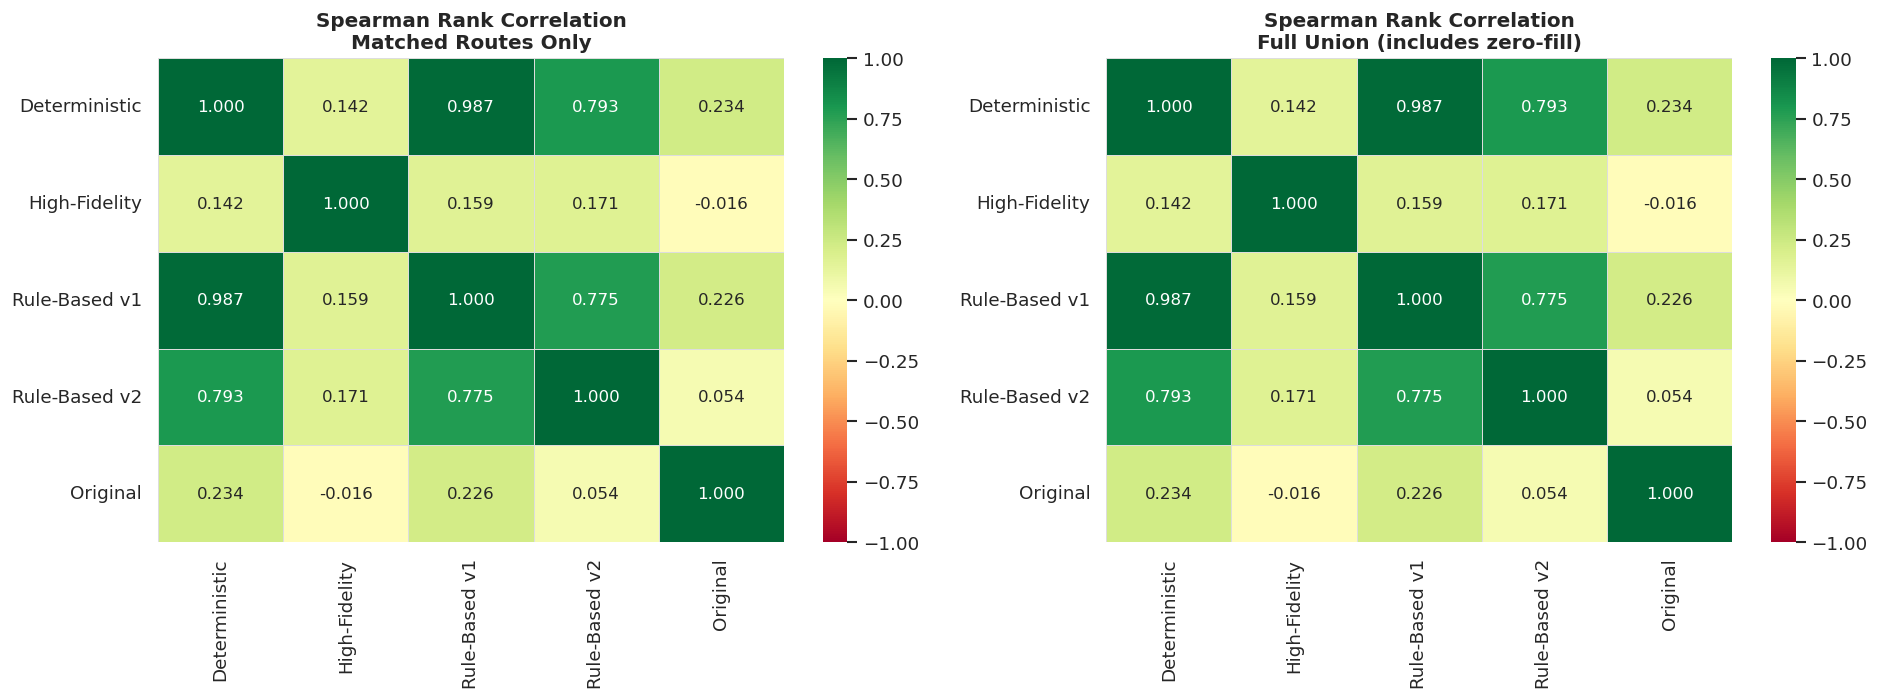

In [53]:
# Visualization: Spearman Heatmaps — Matched Routes vs Full Union

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, matrix, title in [
    (axes[0], corr_matrix,      "Matched Routes Only"),
    (axes[1], corr_matrix_full, "Full Union (includes zero-fill)"),
]:
    sns.heatmap(
        matrix, annot=True, fmt=".3f", cmap="RdYlGn",
        vmin=-1, vmax=1, linewidths=0.5, linecolor="#ddd",
        ax=ax, annot_kws={"fontsize": 10}
    )
    ax.set_title(f"Spearman Rank Correlation\n{title}", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

The left heatmap uses only routes that appear with non-zero boardings in both the synthetic trial and the original 2019 data. This is the more reliable measure of route-ranking agreement. The right heatmap includes the full union index with zero-filled entries, which causes strong negative values between trials and Original because the two datasets occupy different halves of the 124-route union. The inter-trial correlations in the upper-left block are valid in both versions. The trial-vs-Original values are only meaningful in the left heatmap.

### 5.4 Synthetic vs Original per Route

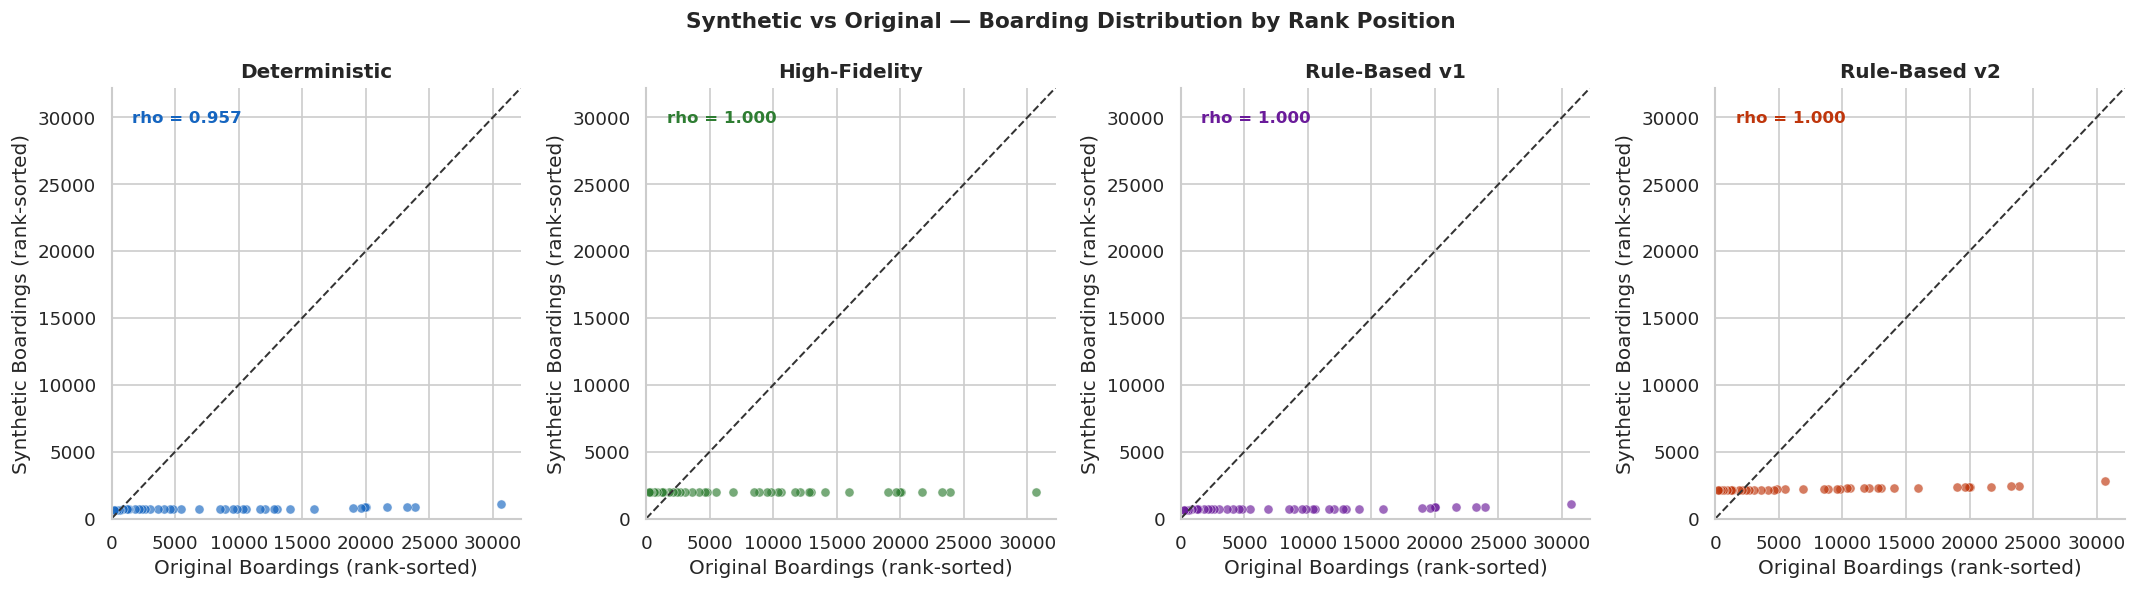

In [54]:
# Visualization: Synthetic vs Original — Boarding Distribution by Rank
# Since route names likely do not match, we compare the two distributions
# by rank-sorting each independently. Each point is one rank position.
# This shows whether the spread and scale align, not route-level identity.

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Synthetic vs Original — Boarding Distribution by Rank Position",
             fontsize=13, fontweight="bold")

orig_vals = combined_df["Original"][combined_df["Original"] > 0].values
orig_sorted = np.sort(orig_vals)[::-1]

for ax, t_name in zip(axes, FULL_TRIALS):
    trial_vals   = combined_df[t_name][combined_df[t_name] > 0].values
    trial_sorted = np.sort(trial_vals)[::-1]
    n = min(len(orig_sorted), len(trial_sorted))
    x, y = orig_sorted[:n], trial_sorted[:n]

    ax.scatter(x, y, color=FULL_COLORS[t_name], alpha=0.65, s=30,
               edgecolors="white", linewidths=0.4)
    lim = float(max(x.max(), y.max())) * 1.05
    ax.plot([0, lim], [0, lim], color="#333", linestyle="--", linewidth=1.2)

    rho, _ = stats.spearmanr(x, y)
    ax.text(0.05, 0.92, f"rho = {rho:.3f}", transform=ax.transAxes,
            fontsize=10, fontweight="bold", color=FULL_COLORS[t_name])
    ax.set_title(FULL_LABELS[t_name], fontweight="bold")
    ax.set_xlabel("Original Boardings (rank-sorted)")
    ax.set_ylabel("Synthetic Boardings (rank-sorted)")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Each point is one rank position rather than one named route. The x-axis is the original 2019 boarding value at that rank and the y-axis is the synthetic value at the same rank. Points along the diagonal mean the synthetic model produces the same boarding level as the original at that rank. Points below the diagonal mean the model produces lower boardings than the original at equivalent rank positions. High-Fidelity and Rule-Based v2 should sit closer to the diagonal because their baselines are calibrated to observed ridership levels. Deterministic and Rule-Based v1 should cluster below the diagonal because their base demand is initialised conservatively.

### 5.5 Error Metrics

In [55]:
# Error metrics on shared non-zero normalized routes
# If shared routes = 0, reports N/A with explanation rather than empty table

rows = []
for t_name in FULL_TRIALS:
    idx = shared_nonzero(combined_df, t_name)
    t_total = combined_df[t_name].sum()
    o_total = combined_df["Original"].sum()
    vol_pct = (t_total - o_total) / o_total * 100 if o_total > 0 else np.nan

    if len(idx) < 2:
        rows.append({
            "Trial"         : t_name,
            "Model"         : FULL_LABELS[t_name],
            "Shared Routes" : 0,
            "Volume Diff %"  : f"{vol_pct:+.1f}" if not np.isnan(vol_pct) else "N/A",
            "MAE"           : "N/A",
            "MAPE %"        : "N/A",
            "RMSE"          : "N/A",
            "Bias"          : "N/A",
            "Spearman rho"  : "N/A",
        })
        continue

    orig  = combined_df.loc[idx, "Original"]
    synth = combined_df.loc[idx, t_name]
    valid = np.isfinite(orig) & np.isfinite(synth)
    orig, synth = orig[valid], synth[valid]
    if len(orig) < 2:
        rows.append({"Trial": t_name, "Model": FULL_LABELS[t_name],
                     "Shared Routes": 0, "Note": "Insufficient valid rows"})
        continue

    mae    = (synth - orig).abs().mean()
    mape   = ((synth - orig).abs() / orig.replace(0, np.nan)).mean() * 100
    rmse   = np.sqrt(((synth - orig) ** 2).mean())
    bias   = (synth - orig).mean()
    rho, _ = stats.spearmanr(synth, orig)

    rows.append({
        "Trial"        : t_name,
        "Model"        : FULL_LABELS[t_name],
        "Shared Routes": len(orig),
        "Volume Diff %" : f"{vol_pct:+.1f}" if not np.isnan(vol_pct) else "N/A",
        "MAE"          : f"{mae:,.1f}",
        "MAPE %"       : f"{mape:.1f}",
        "RMSE"         : f"{rmse:,.1f}",
        "Bias"         : f"{bias:+,.1f}",
        "Spearman rho" : f"{rho:.4f}",
    })

err_df = pd.DataFrame(rows).set_index("Model")
print("Route-Level Error Metrics vs Original 2019")
print("Volume Diff % is computed across the full union index regardless of name matching.")
display(err_df)

Route-Level Error Metrics vs Original 2019
Volume Diff % is computed across the full union index regardless of name matching.


,Trial,Shared Routes,Volume Diff %,MAE,MAPE %,RMSE,Bias,Spearman rho
Model,,,,,,,,
Deterministic,Trial 5,38,-87.5,"8,806.4",84.1,"11,904.0","-8,748.8",0.1723
High-Fidelity,Trial 6,38,-64.1,"8,025.6",121.2,"11,014.3","-7,486.1",-0.4356
Rule-Based v1,Trial 7,38,-87.5,"8,805.9",84.1,"11,903.6","-8,748.2",0.1642
Rule-Based v2,Trial 9,38,-60.9,"7,948.0",130.5,"10,917.6","-7,283.2",-0.3896


Volume Diff is computed across all routes in the union index and is valid regardless of whether route names matched. It shows how much total boarding mass each synthetic model produces relative to the original 2019 total. Route-level error metrics (MAE, RMSE, Bias) are only computed when named routes are shared and will show N/A when route matching failed. If matching failed, the rank-based scatter in 5.4 and the distribution comparison in 5.6 are the more reliable tools for assessing how well each model reproduces the shape and scale of 2019 ridership.

The comparative results are subject to several limitations. Route matching depends on string normalization and a numeric-prefix fallback, and may still fail if the original ridership file uses a naming scheme that is structurally different from GTFS short names. The route-level metric is the mean of average daily boardings rather than a true annual total, which improves comparability but does not capture temporal variation within the year. All per-route metrics should be treated as indicative rather than definitive given these constraints.

### 5.6 Signed Error Distribution

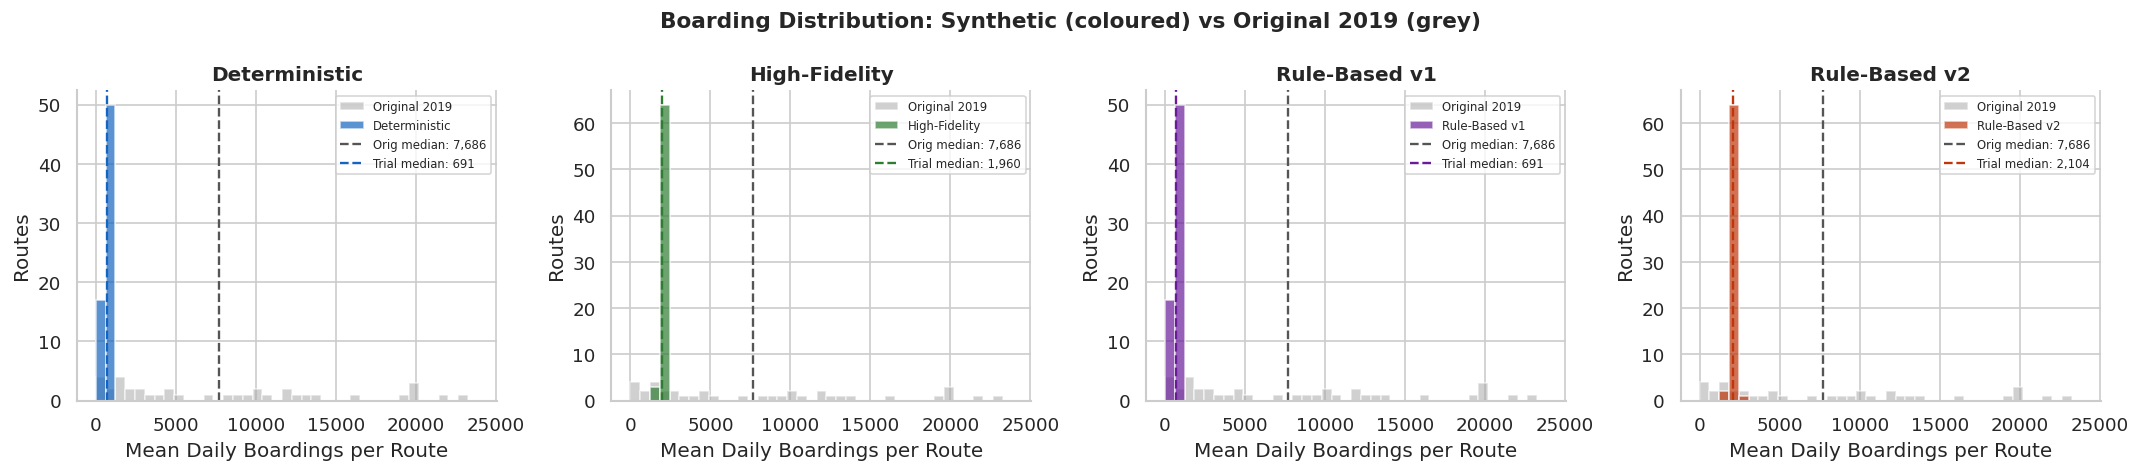

In [56]:
# Visualization: Route-level mean boarding distributions — Synthetic vs Original 2019
# Overlapping histograms comparing the distribution shape of each Full trial
# against the 2019 original. A close shape match indicates good distributional fidelity.

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Boarding Distribution: Synthetic (coloured) vs Original 2019 (grey)",
             fontsize=13, fontweight="bold")

orig_vals = combined_df["Original"][combined_df["Original"] > 0].values

for ax, t_name in zip(axes, FULL_TRIALS):
    trial_vals = combined_df[t_name][combined_df[t_name] > 0].values
    all_vals   = np.concatenate([orig_vals, trial_vals])
    bins       = np.linspace(0, np.percentile(all_vals, 99), 40)

    ax.hist(orig_vals,  bins=bins, color="#aaaaaa", alpha=0.55,
            edgecolor="white", label="Original 2019")
    ax.hist(trial_vals, bins=bins, color=FULL_COLORS[t_name], alpha=0.70,
            edgecolor="white", label=FULL_LABELS[t_name])

    ax.axvline(np.median(orig_vals),  color="#555", linestyle="--", linewidth=1.4,
               label=f"Orig median: {np.median(orig_vals):,.0f}")
    ax.axvline(np.median(trial_vals), color=FULL_COLORS[t_name],
               linestyle="--", linewidth=1.4,
               label=f"Trial median: {np.median(trial_vals):,.0f}")

    ax.set_title(FULL_LABELS[t_name], fontweight="bold")
    ax.set_xlabel("Mean Daily Boardings per Route")
    ax.set_ylabel("Routes")
    ax.legend(fontsize=7)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

This chart shows the shape of the boarding distribution for each Full trial against the 2019 original. The grey histogram is the original and the coloured one is the synthetic trial. Vertical dashed lines show the median of each. A trial whose coloured histogram overlaps well with the grey one and whose median sits near the original median is producing boardings at the right scale. Trials sitting far to the left are producing systematically lower boardings than the original. High-Fidelity and Rule-Based v2 are expected to overlap the original most closely given their higher absolute boarding values.

### 5.7 Monthly Trend vs Original

In [57]:
# Original 2019 monthly totals
monthly_orig = rd_2019.groupby("Month")["Average Daily Boardings"].sum().reset_index()

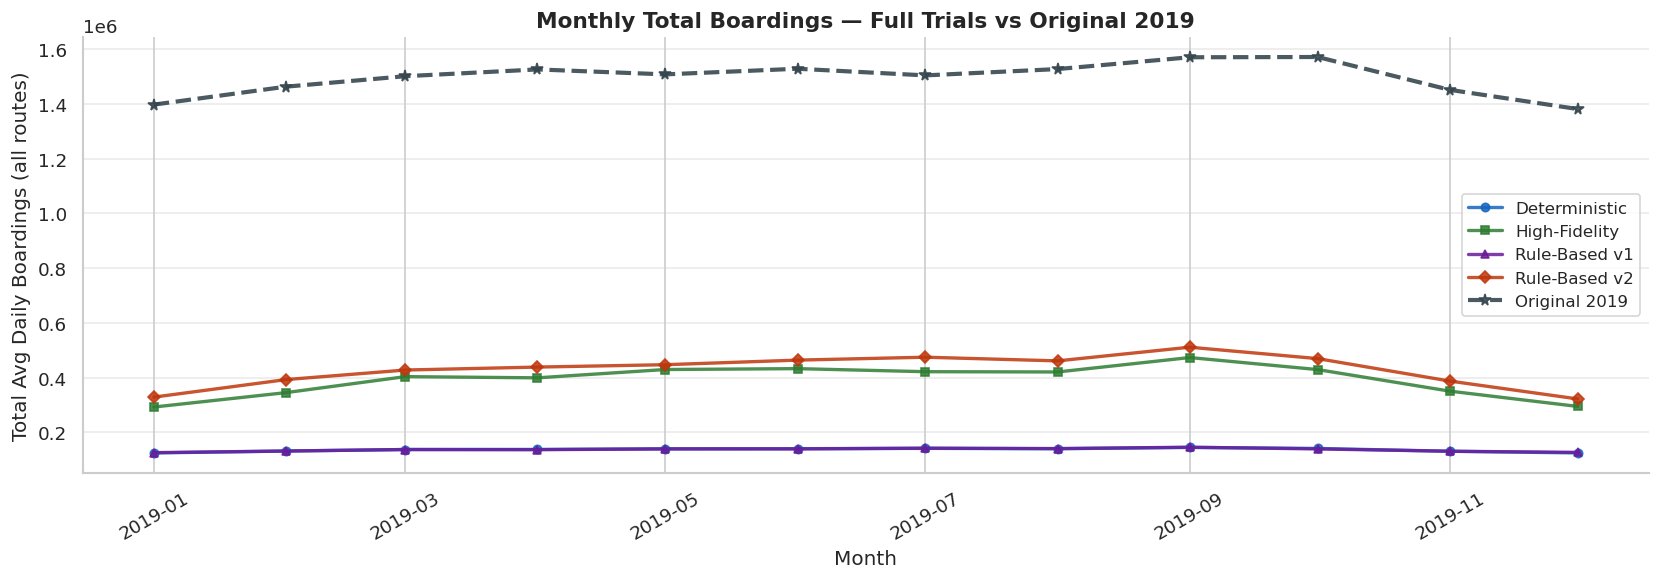

In [58]:
# Visualization: Monthly Total Boardings vs Original 2019

markers = ["o", "s", "^", "D"]

fig, ax = plt.subplots(figsize=(14, 5))

for i, t_name in enumerate(FULL_TRIALS):
    df      = trials[t_name]
    monthly = df.groupby("Month")["Average Daily Boardings"].sum().reset_index()
    ax.plot(monthly["Month"], monthly["Average Daily Boardings"],
            marker=markers[i], linewidth=2, color=FULL_COLORS[t_name],
            label=FULL_LABELS[t_name], alpha=0.85, markersize=5)

ax.plot(monthly_orig["Month"], monthly_orig["Average Daily Boardings"],
        linewidth=2.5, color=FULL_COLORS["Original"], linestyle="--",
        label="Original 2019", alpha=0.9, marker="*", markersize=7)

ax.set_title("Monthly Total Boardings — Full Trials vs Original 2019",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Avg Daily Boardings (all routes)")
ax.legend(fontsize=10)
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

The monthly curves show whether synthetic trials follow the same seasonal pattern as the original 2019 data. The original dips in summer and peaks in autumn. A trial that tracks this shape is capturing the seasonal structure correctly even if its absolute level is lower. The vertical gap between synthetic and original reflects the route coverage difference and conservative base demand, not a seasonal calibration failure. High-Fidelity is expected to track the original shape most closely because its monthly calibration is derived from 2019 data.

### 5.8 Machine Learning Fidelity Test

A Random Forest is trained on each synthetic Full trial and evaluated on a fixed 20 percent hold-out from the original 2019 data. The baseline is trained and tested only on the original 2019 data using the same pipeline. Route, service category, service day, and month are encoded consistently through a shared OneHotEncoder so that categories are not remapped between training and evaluation. A negative R2 on the original hold-out means the model trained on synthetic data predicts worse than simply using the mean of the hold-out values. This is expected when the synthetic boarding scale differs substantially from the original, because the model learns the wrong numeric range and cannot correct for it at prediction time.

In [59]:
# Shared feature engineering for the ML fidelity test

ML_CATEGORICAL_COLS = ["Route", "Service Category", "Service Day of the Week"]
ML_NUMERIC_COLS     = ["month_int"]

def prepare_ml_frame(df):
    d = df.copy().dropna(subset=["Average Daily Boardings"])
    # normalize_route_label is defined in cell 102 as normalize_gtfs_short
    d["Route"] = d["Route"].apply(normalize_route_label).fillna("missing_route")
    for col in ["Service Category", "Service Day of the Week"]:
        if col not in d.columns:
            d[col] = "missing"
        d[col] = d[col].astype(str).fillna("missing")
    if "Month" in d.columns and d["Month"].notna().any():
        d["month_int"] = pd.to_datetime(d["Month"]).dt.month.astype(int)
    else:
        d["month_int"] = 1
    return d[ML_CATEGORICAL_COLS + ML_NUMERIC_COLS].copy(), d["Average Daily Boardings"].astype(float)

def build_rf_pipeline():
    preprocessor = ColumnTransformer(transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), ML_CATEGORICAL_COLS),
        ("num", "passthrough", ML_NUMERIC_COLS),
    ])
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))
    ])

In [60]:
# Original hold-out and baseline model

X_orig, y_orig = prepare_ml_frame(rd_2019)
X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_orig, y_orig, test_size=0.20, random_state=42
)

rf_base = build_rf_pipeline()
rf_base.fit(X_train_o, y_train_o)
y_pred_base = rf_base.predict(X_test_o)

base_r2   = r2_score(y_test_o, y_pred_base)
base_mae  = mean_absolute_error(y_test_o, y_pred_base)
base_rmse = np.sqrt(((y_pred_base - y_test_o) ** 2).mean())

print("Baseline trained on Original:")
print(f"  R2   : {base_r2:.4f}")
print(f"  MAE  : {base_mae:,.1f}")
print(f"  RMSE : {base_rmse:,.1f}")

Baseline trained on Original:
  R2   : 0.9916
  MAE  : 406.3
  RMSE : 703.2


In [61]:
# Train on each synthetic Full trial, evaluate on original hold-out

ml_results = {}

for t_name in FULL_TRIALS:
    df_s = trials[t_name]
    X_s, y_s = prepare_ml_frame(df_s)
    rf = build_rf_pipeline()
    rf.fit(X_s, y_s)
    y_pred = rf.predict(X_test_o)
    ml_results[t_name] = {
        "r2"  : r2_score(y_test_o, y_pred),
        "mae" : mean_absolute_error(y_test_o, y_pred),
        "rmse": np.sqrt(((y_pred - y_test_o) ** 2).mean()),
        "pred": y_pred,
    }

In [62]:
# ML Fidelity Summary Table

ml_rows = [{
    "Training Data"   : "Original (Baseline)",
    "R2 on Original"  : f"{base_r2:.4f}",
    "MAE on Original" : f"{base_mae:,.1f}",
    "RMSE on Original": f"{base_rmse:,.1f}",
    "Fidelity Ratio"  : "1.000",
}]

for t_name in FULL_TRIALS:
    r  = ml_results[t_name]
    fi = r['r2'] / base_r2 if base_r2 > 0 else np.nan
    ml_rows.append({
        "Training Data"   : f"{t_name} ({FULL_LABELS[t_name]})",
        "R2 on Original"  : f"{r['r2']:.4f}",
        "MAE on Original" : f"{r['mae']:,.1f}",
        "RMSE on Original": f"{r['rmse']:,.1f}",
        "Fidelity Ratio"  : f"{fi:.3f}" if not np.isnan(fi) else "N/A",
    })

ml_df = pd.DataFrame(ml_rows).set_index("Training Data")
print("ML Fidelity Summary")
display(ml_df)

ML Fidelity Summary


,R2 on Original,MAE on Original,RMSE on Original,Fidelity Ratio
Training Data,,,,
Original (Baseline),0.9916,406.3,703.2,1.000
Trial 5 (Deterministic),-0.7657,"6,775.8","10,181.5",-0.772
Trial 6 (High-Fidelity),-0.4726,"6,006.5","9,298.2",-0.477
Trial 7 (Rule-Based v1),-0.7657,"6,775.8","10,181.4",-0.772
Trial 9 (Rule-Based v2),-0.4767,"5,979.3","9,310.9",-0.481


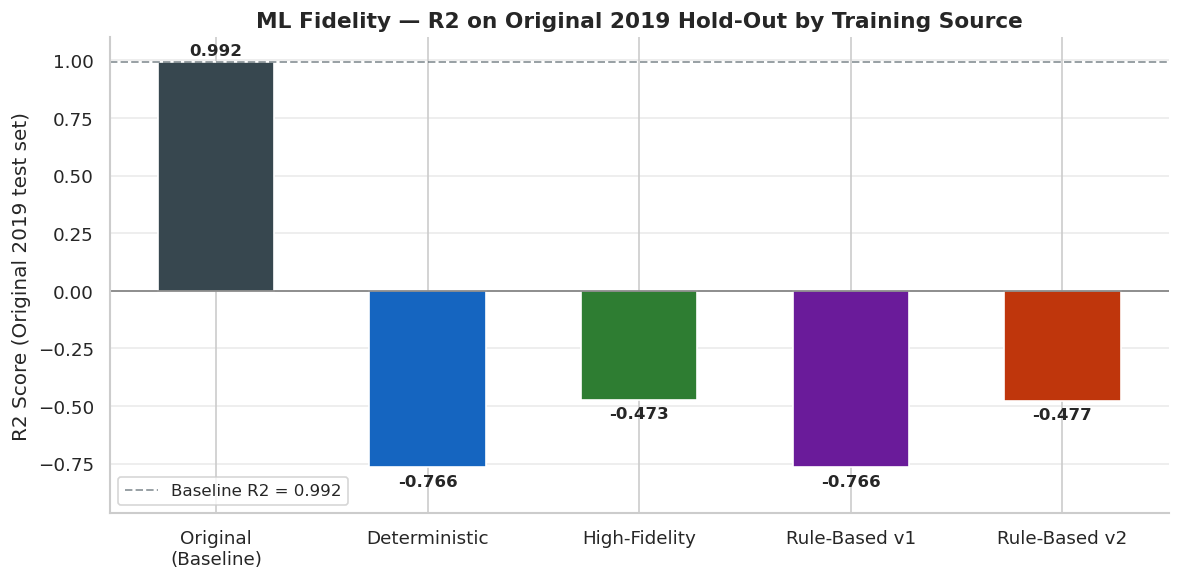

In [63]:
# Visualization: ML Fidelity — R2 by Training Source

r2_vals    = [base_r2] + [ml_results[t]["r2"] for t in FULL_TRIALS]
bar_labels = ["Original\n(Baseline)"] + [FULL_LABELS[t] for t in FULL_TRIALS]
bar_colors = [FULL_COLORS["Original"]] + [FULL_COLORS[t] for t in FULL_TRIALS]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(bar_labels, r2_vals, color=bar_colors, edgecolor="white", width=0.55)

for bar, val in zip(bars, r2_vals):
    label_y = val + 0.03 if val >= 0 else val - 0.08
    ax.text(bar.get_x() + bar.get_width() / 2, label_y,
            f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")

ax.axhline(0, color="#333", linewidth=1.0, alpha=0.6)
ax.axhline(base_r2, color="#37474F", linestyle="--", linewidth=1.2, alpha=0.5,
           label=f"Baseline R2 = {base_r2:.3f}")

y_min = min(min(r2_vals) - 0.20, -0.20)
y_max = 1.10
ax.set_ylim(y_min, y_max)

ax.set_title("ML Fidelity — R2 on Original 2019 Hold-Out by Training Source",
             fontsize=13, fontweight="bold")
ax.set_ylabel("R2 Score (Original 2019 test set)")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

The baseline R2 of 0.99 confirms the original 2019 data is internally self-consistent with route, category, day type, and month as predictors. Synthetic models that produce negative R2 values are not simply performing poorly relative to a high standard. A negative R2 means the model predicts worse than a flat mean prediction, which happens when the boarding scale learned from synthetic data is so different from the original that every prediction lands in the wrong range. This is not a failure of the generation model's internal logic but a reflection of the scale gap between synthetic and real boardings. High-Fidelity and Rule-Based v2 are expected to be closest to zero or positive because their boarding levels are closer to the original scale.

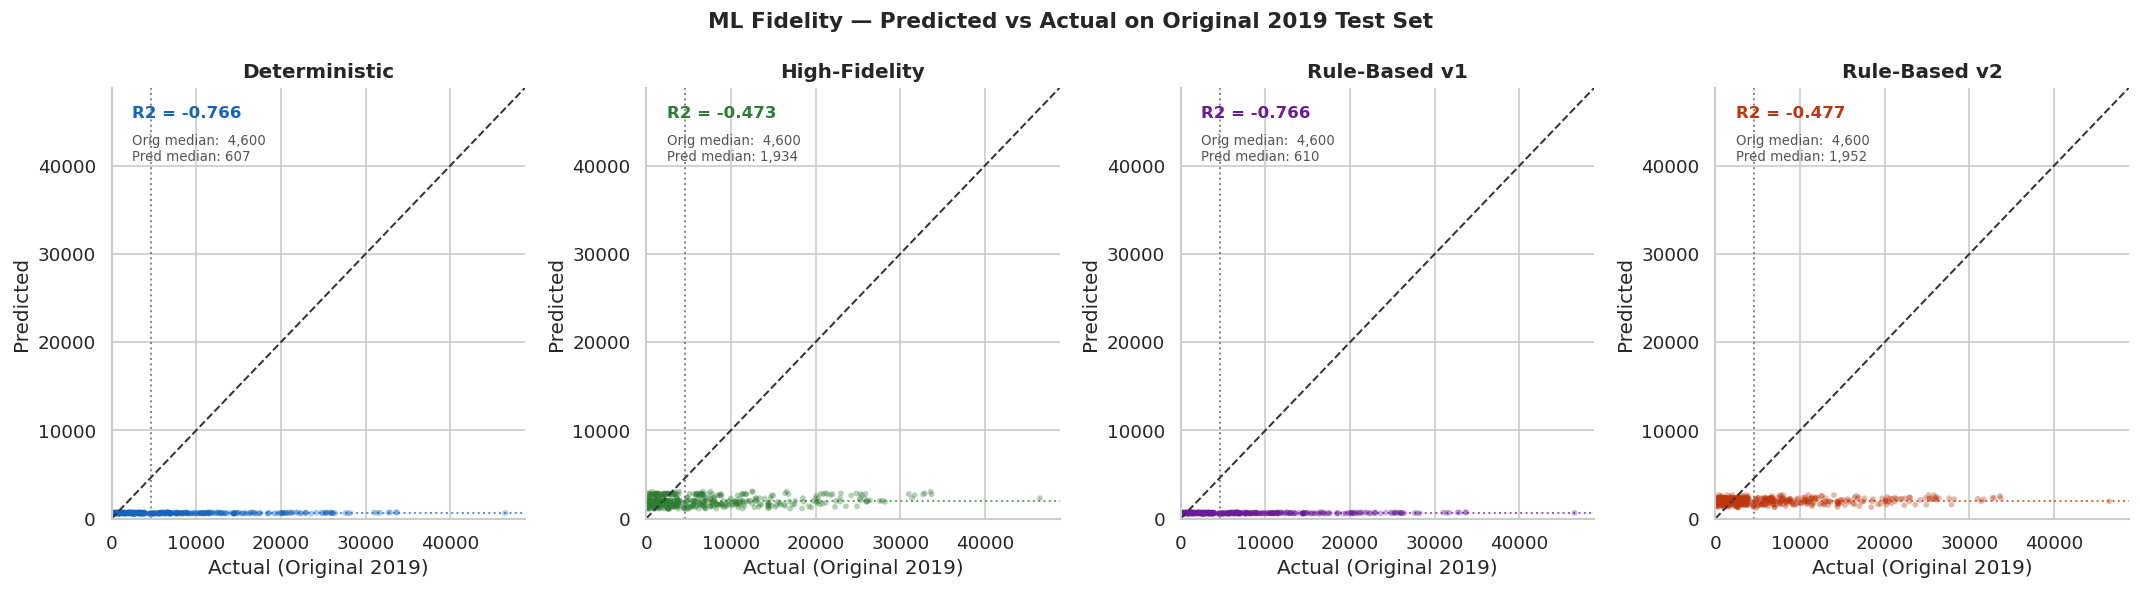

In [64]:
# Visualization: Predicted vs Actual on Original 2019 Test Set

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("ML Fidelity — Predicted vs Actual on Original 2019 Test Set",
             fontsize=13, fontweight="bold")

for ax, t_name in zip(axes, FULL_TRIALS):
    y_pred = ml_results[t_name]["pred"]
    r2     = ml_results[t_name]["r2"]
    actual = y_test_o.values
    valid  = np.isfinite(y_pred) & np.isfinite(actual)

    if valid.sum() < 2:
        ax.set_title(f"{FULL_LABELS[t_name]}\n(no valid predictions)", fontweight="bold")
        continue

    # Use the full actual range for the diagonal so the prediction cluster
    # position is visible relative to where correct predictions would land
    x_max = float(actual[valid].max()) * 1.05
    y_max = float(max(actual[valid].max(), y_pred[valid].max())) * 1.05
    lim   = max(x_max, y_max)

    ax.scatter(actual[valid], y_pred[valid], color=FULL_COLORS[t_name],
               alpha=0.35, s=12, edgecolors="none")
    ax.plot([0, lim], [0, lim], color="#333", linestyle="--", linewidth=1.2)

    med_actual = np.median(actual[valid])
    med_pred   = np.median(y_pred[valid])
    ax.axhline(med_pred,   color=FULL_COLORS[t_name], linewidth=1.2, alpha=0.7, linestyle=":")
    ax.axvline(med_actual, color="#555", linewidth=1.2, alpha=0.7, linestyle=":")

    ax.text(0.05, 0.93, f"R2 = {r2:.3f}", transform=ax.transAxes,
            fontsize=10, fontweight="bold", color=FULL_COLORS[t_name])
    ax.text(0.05, 0.83,
            f"Orig median:  {med_actual:,.0f}\nPred median: {med_pred:,.0f}",
            transform=ax.transAxes, fontsize=8, color="#555")

    ax.set_title(FULL_LABELS[t_name], fontweight="bold")
    ax.set_xlabel("Actual (Original 2019)")
    ax.set_ylabel("Predicted")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

The dotted lines mark the median of actual original values (vertical) and median of predicted values (horizontal). Their intersection shows where most predictions land relative to where they should be. When the prediction median sits well below the actual median, the model has learned to predict in the synthetic boarding range rather than the original range. High-Fidelity and Rule-Based v2 should show less vertical displacement because their training distributions have higher boarding values and are closer in scale to the original. The diagonal line shows the ideal prediction target: a model that predicted perfectly would produce a dense cluster along that line.

## Section 6 — ML-Generated Synthetic Data

This section trains a regression model directly on the original 2019 SFMTA ridership data, uses it to generate a synthetic prediction frame covering the same routes, months, service categories, and day types as the original, then compares that ML-generated dataset against the original using the same charts used for the simulation trials in Section 5. This establishes the best achievable synthetic fidelity when the generator has full access to the original distribution and serves as a ceiling benchmark for the simulation-based trials.

In [65]:
# Train regression model on original 2019 and generate synthetic prediction frame

# Train on the full original 2019 dataset (no train/test split — we want every row)
X_train_full, y_train_full = prepare_ml_frame(rd_2019)

ml_gen_pipeline = build_rf_pipeline()
ml_gen_pipeline.fit(X_train_full, y_train_full)

# Build a unique combination frame (one row per Route/Month/Category/DayType)
# that matches the original schema exactly — this becomes the synthetic frame
pred_input = (
    rd_2019[["Month", "Route", "Service Category", "Service Day of the Week"]]
    .copy()
    .drop_duplicates()
    .reset_index(drop=True)
)

# Add a temporary boarding column so prepare_ml_frame can run without error
pred_input["Average Daily Boardings"] = 0.0

# prepare_ml_frame applies the same normalisation the pipeline was fitted on
X_gen, _ = prepare_ml_frame(pred_input)

# Predict and attach to the output frame (keep original Route for display)
pred_input["Average Daily Boardings"] = ml_gen_pipeline.predict(X_gen)
ml_synthetic_frame = pred_input.drop(columns=["Average Daily Boardings"]).copy()
ml_synthetic_frame["Average Daily Boardings"] = ml_gen_pipeline.predict(X_gen)

print(f"ML synthetic frame rows   : {len(ml_synthetic_frame):,}")
print(f"ML synthetic frame routes : {ml_synthetic_frame['Route'].nunique()}")
print(f"Prediction range          : {ml_synthetic_frame['Average Daily Boardings'].min():,.0f} to {ml_synthetic_frame['Average Daily Boardings'].max():,.0f}")
print(f"Prediction median         : {ml_synthetic_frame['Average Daily Boardings'].median():,.0f}")
print()
display(ml_synthetic_frame.head(10))

ML synthetic frame rows   : 2,274
ML synthetic frame routes : 77
Prediction range          : 100 to 50,540
Prediction median         : 5,445



,Month,Route,Service Category,Service Day of the Week,Average Daily Boardings
0,2019-01-01,1 California,Frequent Local,Sunday,10248.666667
1,2019-02-01,1 California,Frequent Local,Sunday,10989.666667
2,2019-03-01,1 California,Frequent Local,Sunday,11566.666667
3,2019-04-01,1 California,Frequent Local,Sunday,11053.000000
4,2019-05-01,1 California,Frequent Local,Sunday,10898.000000
5,2019-06-01,1 California,Frequent Local,Sunday,11341.666667
6,2019-07-01,1 California,Frequent Local,Sunday,11164.666667
7,2019-08-01,1 California,Frequent Local,Sunday,11456.000000
8,2019-09-01,1 California,Frequent Local,Sunday,11825.666667
9,2019-10-01,1 California,Frequent Local,Sunday,11700.333333


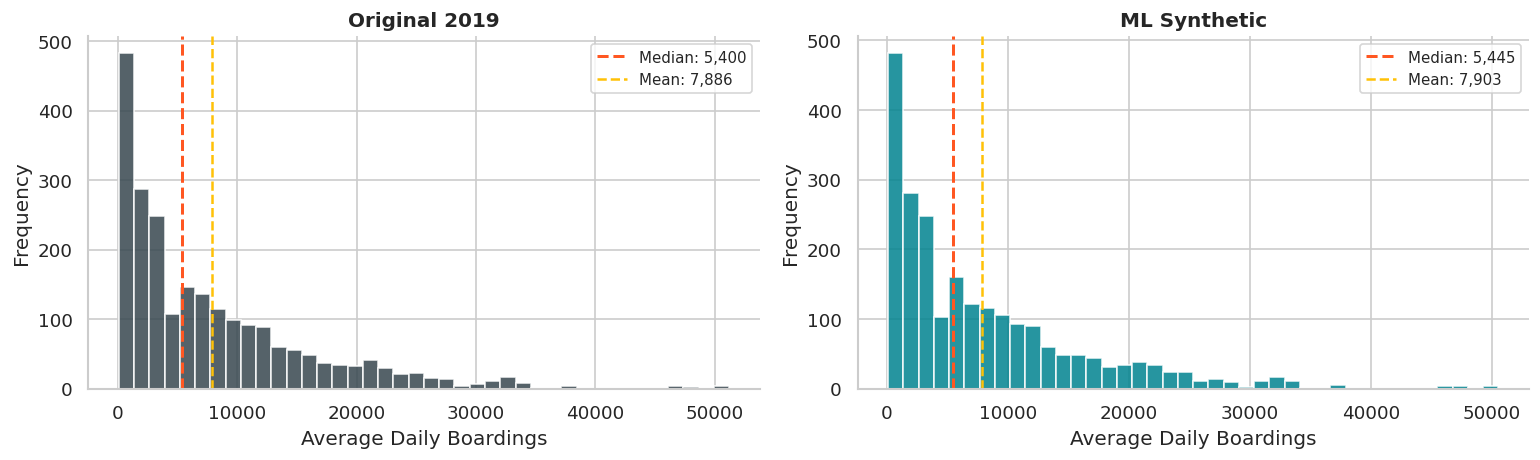

In [66]:
# Visualization: ML Synthetic vs Original 2019 — Boarding Distribution

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, df, label, col in [
    (axes[0], rd_2019,           "Original 2019", "#37474F"),
    (axes[1], ml_synthetic_frame,"ML Synthetic",  "#00838F"),
]:
    vals = df["Average Daily Boardings"].dropna()
    ax.hist(vals, bins=40, color=col, edgecolor="white", alpha=0.85)
    ax.axvline(vals.median(), color="#FF5722", linestyle="--", linewidth=1.8,
               label=f"Median: {vals.median():,.0f}")
    ax.axvline(vals.mean(), color="#FFC107", linestyle="--", linewidth=1.5,
               label=f"Mean: {vals.mean():,.0f}")
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Average Daily Boardings")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

The ML synthetic frame is generated by predicting every row in the original schema, so by construction it should reproduce the original distribution closely. The median and mean of the ML synthetic frame should sit near the original values. Any divergence reflects the degree to which the Random Forest smooths over the extremes of the original distribution, typically compressing the tails toward the mean.

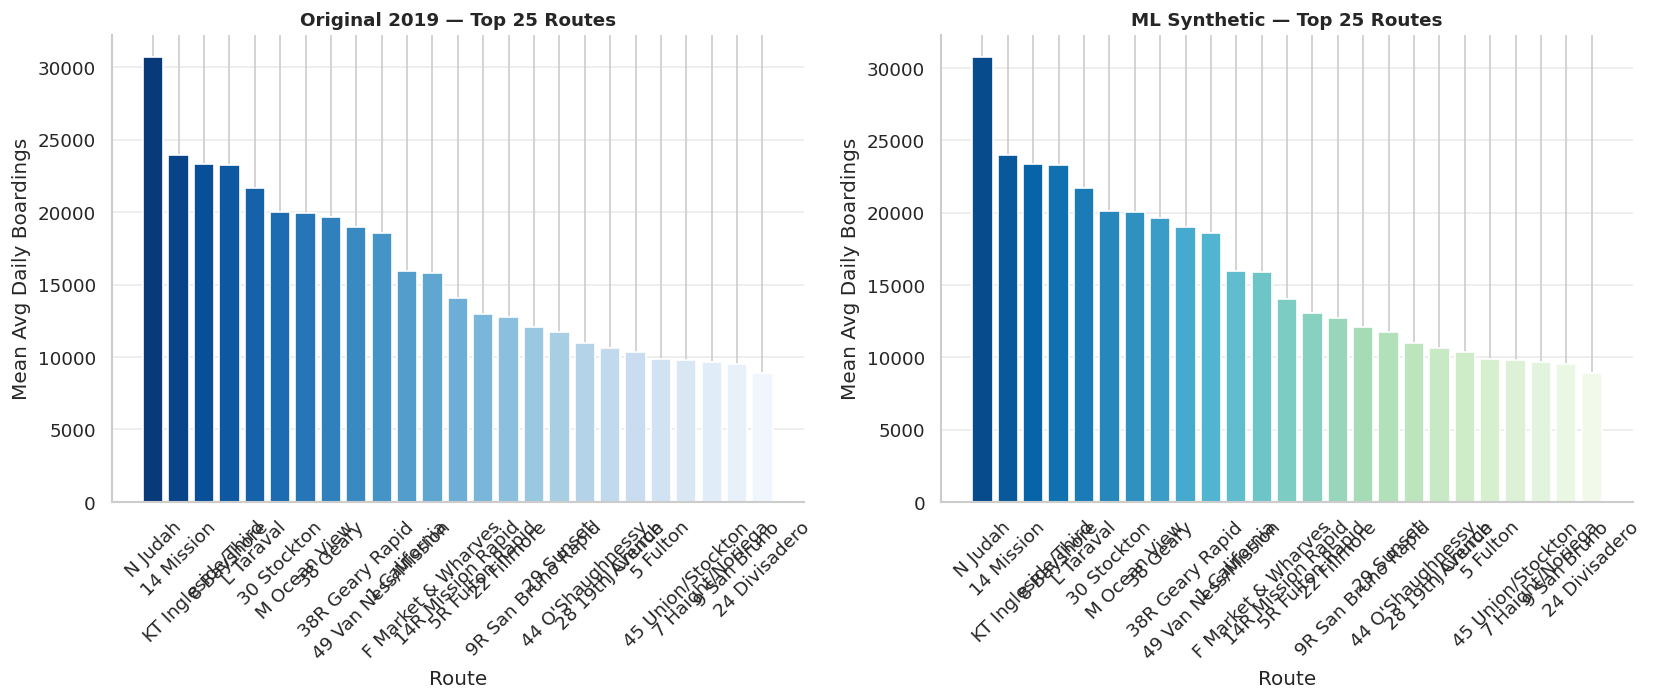

In [67]:
# Visualization: Top 25 Routes — ML Synthetic vs Original 2019

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, df, label, col in [
    (axes[0], rd_2019,           "Original 2019", "#37474F"),
    (axes[1], ml_synthetic_frame,"ML Synthetic",  "#00838F"),
]:
    route_totals = (
        df.groupby("Route")["Average Daily Boardings"]
        .mean()
        .sort_values(ascending=False)
        .head(25)
    )
    palette = sns.color_palette("Blues_r" if col == "#37474F" else "GnBu_r", len(route_totals))
    ax.bar(route_totals.index.astype(str), route_totals.values, color=palette, edgecolor="white")
    ax.set_title(f"{label} — Top 25 Routes", fontsize=11, fontweight="bold")
    ax.set_xlabel("Route")
    ax.set_ylabel("Mean Avg Daily Boardings")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.4)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

The ML synthetic frame should rank the top 25 routes in the same order as the original because the model learned from the same data. Differences in bar height indicate where the model smoothed the original values, typically reducing the highest-demand routes slightly and raising the lowest slightly. Routes that appear in the original top 25 but not in the ML synthetic top 25 indicate the model redistributed their demand across similar routes.

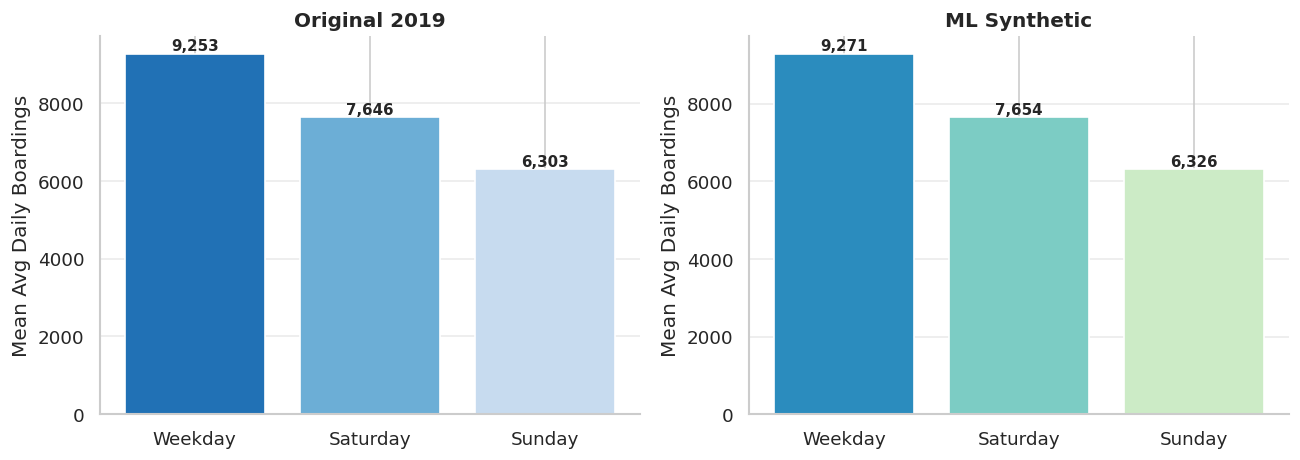

In [68]:
# Visualization: Day-Type Boardings — ML Synthetic vs Original 2019

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, df, label, pal in [
    (axes[0], rd_2019,           "Original 2019", "Blues_r"),
    (axes[1], ml_synthetic_frame,"ML Synthetic",  "GnBu_r"),
]:
    day_avg = df.groupby("Service Day of the Week")["Average Daily Boardings"].mean().sort_values(ascending=False)
    palette = sns.color_palette(pal, len(day_avg))
    bars = ax.bar(day_avg.index, day_avg.values, color=palette, edgecolor="white")
    for bar, val in zip(bars, day_avg.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val * 1.01,
                f"{val:,.0f}", ha="center", fontsize=9, fontweight="bold")
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_ylabel("Mean Avg Daily Boardings")
    ax.grid(axis="y", alpha=0.4)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

The day-type structure in the ML synthetic frame should closely mirror the original since service day is one of the features the model was trained on. If the Saturday and Sunday values diverge from the original, it indicates the model is not capturing the day-type effect cleanly, likely because the interaction between route and day type is not fully separable from month effects with these features alone.

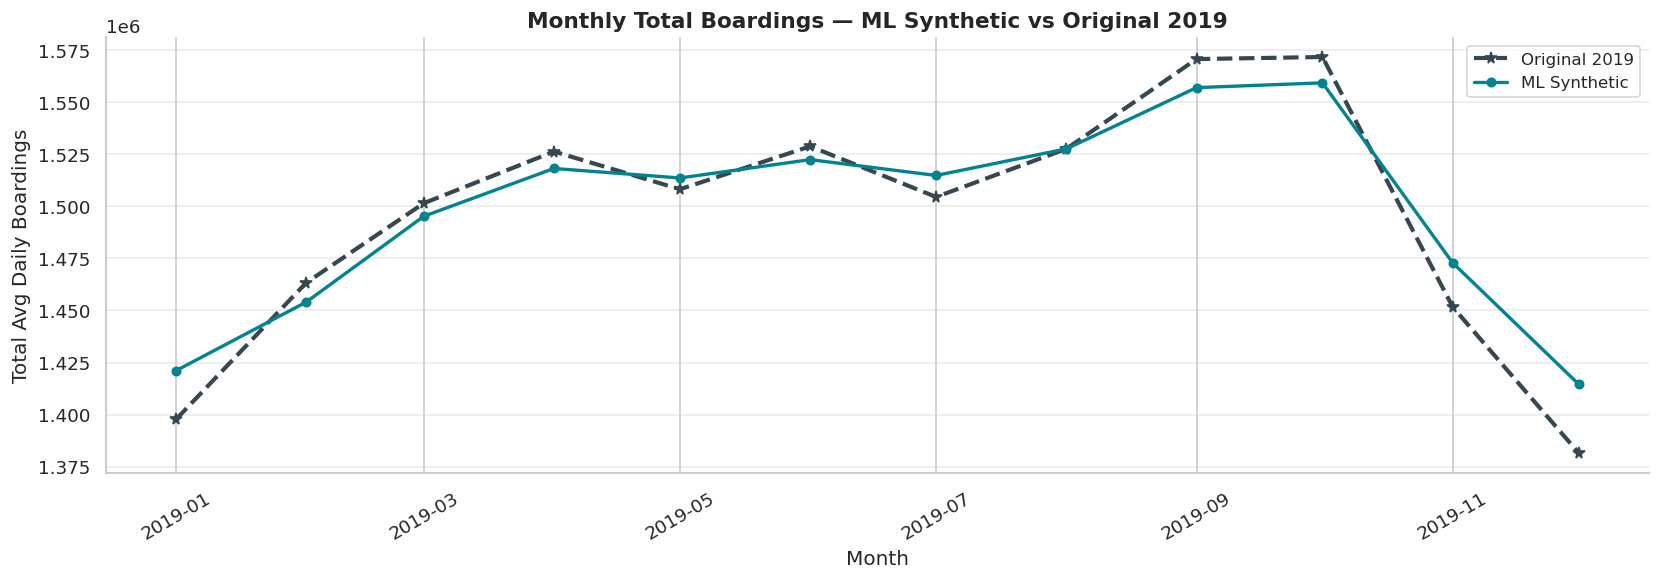

In [69]:
# Visualization: Monthly Trend — ML Synthetic vs Original 2019

monthly_orig = rd_2019.groupby("Month")["Average Daily Boardings"].sum().reset_index()
monthly_ml   = ml_synthetic_frame.groupby("Month")["Average Daily Boardings"].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly_orig["Month"], monthly_orig["Average Daily Boardings"],
        color="#37474F", linewidth=2.5, marker="*", markersize=7,
        linestyle="--", label="Original 2019")
ax.plot(monthly_ml["Month"], monthly_ml["Average Daily Boardings"],
        color="#00838F", linewidth=2, marker="o", markersize=5, label="ML Synthetic")

ax.set_title("Monthly Total Boardings — ML Synthetic vs Original 2019",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Avg Daily Boardings")
ax.legend(fontsize=10)
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

The ML synthetic monthly trend should track the original closely but will tend to be smoother because the Random Forest averages over the training distribution. Peaks and dips in the original that are caused by unusual events or data anomalies in specific months will be partially flattened in the ML synthetic frame. A tight match here confirms the model captured seasonal structure through the month integer feature.

In [70]:
# ML Synthetic vs Original 2019 — Route-Level Comparison Table

ml_series   = ml_synthetic_frame.groupby("Route")["Average Daily Boardings"].mean()
orig_series_ml = rd_2019.groupby("Route")["Average Daily Boardings"].mean()

ml_combined = pd.DataFrame({"ML Synthetic": ml_series, "Original": orig_series_ml}).fillna(0)
ml_shared   = ml_combined[(ml_combined["ML Synthetic"] > 0) & (ml_combined["Original"] > 0)]

mae_ml   = (ml_shared["ML Synthetic"] - ml_shared["Original"]).abs().mean()
rmse_ml  = np.sqrt(((ml_shared["ML Synthetic"] - ml_shared["Original"]) ** 2).mean())
bias_ml  = (ml_shared["ML Synthetic"] - ml_shared["Original"]).mean()
rho_ml, _ = stats.spearmanr(ml_shared["ML Synthetic"], ml_shared["Original"])

print("ML Synthetic vs Original 2019 — Route-Level Error Metrics")
print(f"  Shared routes : {len(ml_shared)}")
print(f"  MAE           : {mae_ml:,.1f}")
print(f"  RMSE          : {rmse_ml:,.1f}")
print(f"  Bias          : {bias_ml:+,.1f}")
print(f"  Spearman rho  : {rho_ml:.4f}")

ML Synthetic vs Original 2019 — Route-Level Error Metrics
  Shared routes : 77
  MAE           : 18.2
  RMSE          : 27.5
  Bias          : +15.0
  Spearman rho  : 0.9999


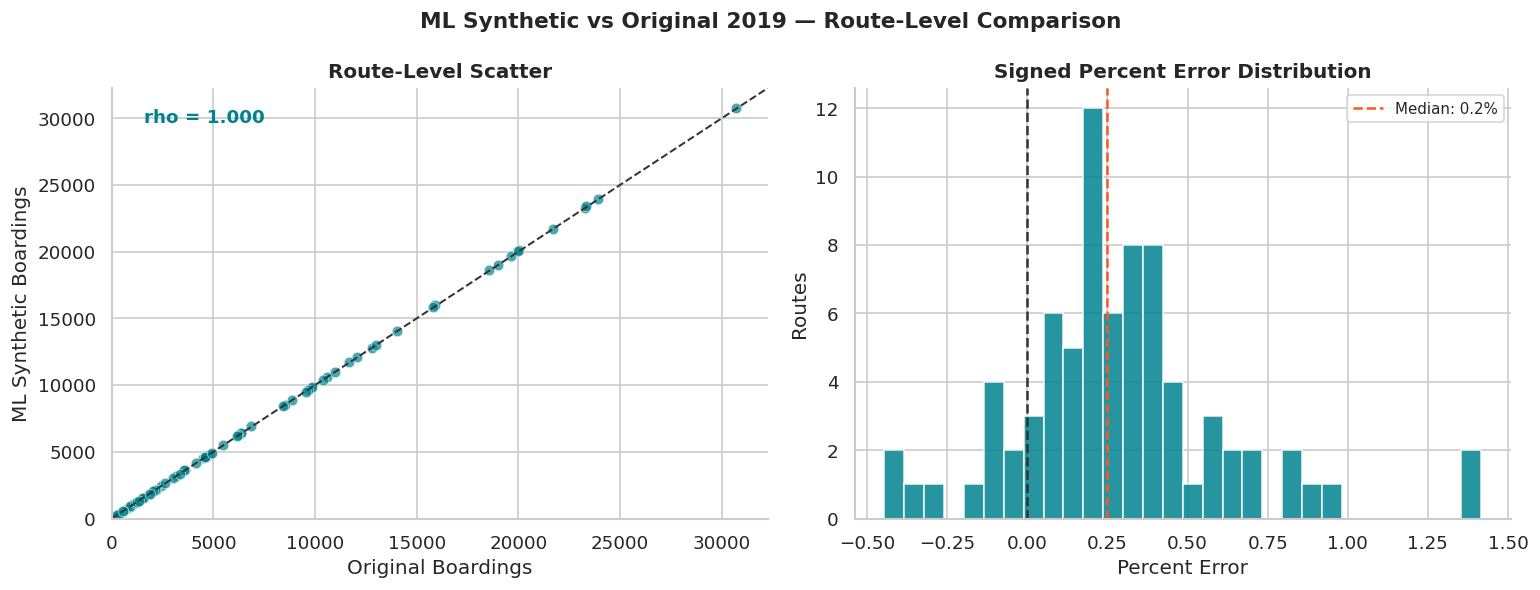

In [71]:
# Visualization: ML Synthetic vs Original — Scatter per Route

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("ML Synthetic vs Original 2019 — Route-Level Comparison",
             fontsize=13, fontweight="bold")

# Left: scatter
ax = axes[0]
x  = ml_shared["Original"]
y  = ml_shared["ML Synthetic"]
ax.scatter(x, y, color="#00838F", alpha=0.7, s=40, edgecolors="white", linewidths=0.4)
lim = float(max(x.max(), y.max())) * 1.05
ax.plot([0, lim], [0, lim], color="#333", linestyle="--", linewidth=1.2)
ax.text(0.05, 0.92, f"rho = {rho_ml:.3f}", transform=ax.transAxes,
        fontsize=11, fontweight="bold", color="#00838F")
ax.set_xlabel("Original Boardings")
ax.set_ylabel("ML Synthetic Boardings")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_title("Route-Level Scatter", fontweight="bold")
sns.despine(ax=ax)

# Right: signed error distribution
ax2 = axes[1]
pct_err = ((ml_shared["ML Synthetic"] - ml_shared["Original"]) / ml_shared["Original"] * 100)
ax2.hist(pct_err, bins=30, color="#00838F", edgecolor="white", alpha=0.85)
ax2.axvline(0, color="#333", linestyle="--", linewidth=1.5)
ax2.axvline(pct_err.median(), color="#FF5722", linestyle="--", linewidth=1.5,
            label=f"Median: {pct_err.median():.1f}%")
ax2.set_xlabel("Percent Error")
ax2.set_ylabel("Routes")
ax2.set_title("Signed Percent Error Distribution", fontweight="bold")
ax2.legend(fontsize=9)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

The scatter plot compares ML synthetic boardings against original values per route. Because the model was trained on the same data it is predicting, the Spearman rho should be close to 1.0 and most points should cluster near the diagonal. Remaining scatter reflects variance that the model could not capture from route, day type, service category, and month alone. The signed error distribution should be centred near zero with a tight spread, establishing the best-case error achievable with these features. This is the ceiling benchmark: simulation-based trials that narrow the gap toward these values are approaching ML-level distributional fidelity.

In [72]:
# Benchmark Table: ML Synthetic ceiling vs simulation trials

benchmark_rows = [{
    "Source"        : "ML Synthetic (ceiling)",
    "MAE"           : f"{mae_ml:,.1f}",
    "RMSE"          : f"{rmse_ml:,.1f}",
    "Bias"          : f"{bias_ml:+,.1f}",
    "Spearman rho"  : f"{rho_ml:.4f}",
    "R2 on Original": "N/A (self-fit)",
}]

for t_name in FULL_TRIALS:
    idx  = shared_nonzero(combined_df, t_name)
    t_total = combined_df[t_name].sum()
    o_total = combined_df["Original"].sum()
    vol_pct = (t_total - o_total) / o_total * 100 if o_total > 0 else np.nan

    if len(idx) >= 2:
        orig_v  = combined_df.loc[idx, "Original"]
        synth_v = combined_df.loc[idx, t_name]
        valid   = np.isfinite(orig_v) & np.isfinite(synth_v)
        orig_v, synth_v = orig_v[valid], synth_v[valid]
        if len(orig_v) >= 2:
            mae_t  = (synth_v - orig_v).abs().mean()
            rmse_t = np.sqrt(((synth_v - orig_v) ** 2).mean())
            bias_t = (synth_v - orig_v).mean()
            rho_t, _ = stats.spearmanr(synth_v, orig_v)
            r2_t   = ml_results[t_name]["r2"]
            benchmark_rows.append({
                "Source"        : f"{t_name} ({FULL_LABELS[t_name]})",
                "MAE"           : f"{mae_t:,.1f}",
                "RMSE"          : f"{rmse_t:,.1f}",
                "Bias"          : f"{bias_t:+,.1f}",
                "Spearman rho"  : f"{rho_t:.4f}",
                "R2 on Original": f"{r2_t:.4f}",
            })
            continue
    r2_t = ml_results[t_name]["r2"]
    benchmark_rows.append({
        "Source"        : f"{t_name} ({FULL_LABELS[t_name]})",
        "MAE"           : "N/A",
        "RMSE"          : "N/A",
        "Bias"          : "N/A",
        "Spearman rho"  : "N/A",
        "R2 on Original": f"{r2_t:.4f}",
    })

bench_df = pd.DataFrame(benchmark_rows).set_index("Source")
print("Benchmark Table — ML Ceiling vs Simulation Trials")
display(bench_df)

Benchmark Table — ML Ceiling vs Simulation Trials


,MAE,RMSE,Bias,Spearman rho,R2 on Original
Source,,,,,
ML Synthetic (ceiling),18.2,27.5,+15.0,0.9999,N/A (self-fit)
Trial 5 (Deterministic),"8,806.4","11,904.0","-8,748.8",0.1723,-0.7657
Trial 6 (High-Fidelity),"8,025.6","11,014.3","-7,486.1",-0.4356,-0.4726
Trial 7 (Rule-Based v1),"8,805.9","11,903.6","-8,748.2",0.1642,-0.7657
Trial 9 (Rule-Based v2),"7,948.0","10,917.6","-7,283.2",-0.3896,-0.4767


The ML ceiling row shows the best achievable error on the 2019 data using Route, Service Category, Service Day, and Month as features. Every simulation trial can be compared against this ceiling to measure how close the simulation is to ML-level distributional fidelity. A simulation trial whose MAE approaches the ML ceiling has successfully reproduced the boarding distribution well enough that the remaining error is comparable to what a well-fitted regression model leaves behind. The R2 on Original column carries over from Section 5.8 and shows the transfer learning performance of each trial, which is a separate and more demanding test.

## References

- **SFMTA Ridership Data:** https://www.sfmta.com/reports/ridership-statistics  
- **GTFS Specification:** https://gtfs.org/schedule/reference/  
- **SFMTA Developer Resources:** https://www.sfmta.com/reports/gtfs-transit-data  
- **ACS Table C08132 — Commute Departure Times:** https://data.census.gov/table/ACS  
- **LODES Origin-Destination Employment Statistics:** https://lehd.ces.census.gov/data/  
- **SF Land Use 2023 — SF Planning Department:** https://data.sfgov.org/